# Caso-taller: ¿Dónde abrir una nueva sede?
## Análisis de Componentes Principales, clasificación de ciudades y recomendación ejecutiva

**Grupo 29 — MIAD Aprendizaje No Supervisado — Módulo 1**

---

### El problema

La empresa evalúa abrir una nueva sede con capacidad para alrededor de 500 empleados entre **329 ciudades candidatas**. Nuestra firma consultora debe construir un primer filtro cuantitativo y responder:

> **¿Qué cinco ciudades deberían avanzar a la fase de *due diligence* y qué evidencia justifica su selección?**

Los datos provienen del **Almanaque Calificado de Lugares** (Boyer y Savageau, 1985) y califican cada ciudad en 9 criterios: *Clima y Terreno, Alojamiento, Cuidado de la salud y el medio ambiente, Crimen, Transporte, Educación, Artes, Recreación* y *Economía*. En **Alojamiento** y **Crimen**, un puntaje **menor** es mejor; en las siete variables restantes, un puntaje **mayor** es mejor.

Este cuaderno documenta de forma reproducible el camino que va desde la estructura estadística de los datos (PCA) hasta la construcción de un índice, un ranking, y finalmente una recomendación empresarial.

### Contenido

1. [Exploración de los datos](#paso1)
2. [Cálculo de los componentes principales](#paso2)
3. [Interpretación de los componentes](#paso3)
4. [Construcción del índice y del ranking](#paso4)
5. [Evaluación de la robustez y selección de finalistas](#paso5)
6. Formulación de la recomendación *(próxima sesión)*

<a id='paso1'></a>
## Paso 1. Exploración de los datos

Antes de calcular cualquier componente principal necesitamos entender la calidad, la escala y la estructura de correlación de los datos. Esta sección responde de forma explícita a las preguntas guía del taller:

- ¿Cuántas relaciones por pares existen entre las nueve variables?
- ¿Qué variables presentan escalas muy diferentes?
- ¿Qué consecuencias tendría aplicar PCA sin estandarizar?
- ¿Qué criterios están más correlacionados y qué hipótesis podrían explicar esas relaciones?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import comb

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

RANDOM_STATE = 42

### 1.1 Carga y estructura general

In [2]:
df = pd.read_csv('lugares.csv', encoding='utf-8-sig')
df = df.set_index('Ciudad')

print(f"Dimensiones: {df.shape[0]} ciudades x {df.shape[1]} variables")
df.head()

Dimensiones: 329 ciudades x 9 variables


,Clima y Terreno,Alojamiento,Cuidado de la salud y el medio ambiente,Crimen,Transporte,Educación,Artes,Recreación,Economía
Ciudad,,,,,,,,,
"Abilene,TX",521,6200,237,923,4031,2757,996,1405,7633
"Akron,OH",575,8138,1656,886,4883,2438,5564,2632,4350
"Albany,GA",468,7339,618,970,2531,2560,237,859,5250
"Albany-Schenectady-Troy,NY",476,7908,1431,610,6883,3399,4655,1617,5864
"Albuquerque,NM",659,8393,1853,1483,6558,3026,4496,2612,5727


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 329 entries, Abilene,TX to Yuba-City,CA
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype
---  ------                                   --------------  -----
 0   Clima y Terreno                          329 non-null    int64
 1   Alojamiento                              329 non-null    int64
 2   Cuidado de la salud y el medio ambiente  329 non-null    int64
 3   Crimen                                   329 non-null    int64
 4   Transporte                               329 non-null    int64
 5   Educación                                329 non-null    int64
 6   Artes                                    329 non-null    int64
 7   Recreación                               329 non-null    int64
 8   Economía                                 329 non-null    int64
dtypes: int64(9)
memory usage: 25.7+ KB


In [4]:
missing = df.isna().sum()
n_dupes = df.index.duplicated().sum()

print("Valores faltantes por variable:")
print(missing)
print(f"\nCiudades con nombre duplicado: {n_dupes}")

Valores faltantes por variable:
Clima y Terreno                            0
Alojamiento                                0
Cuidado de la salud y el medio ambiente    0
Crimen                                     0
Transporte                                 0
Educación                                  0
Artes                                      0
Recreación                                 0
Economía                                   0
dtype: int64

Ciudades con nombre duplicado: 0


El conjunto de datos está completo: **329 ciudades únicas, sin valores faltantes**. Las nueve variables son numéricas (puntajes construidos por el Almanaque a partir de indicadores subyacentes), por lo que no se requieren pasos de limpieza ni imputación antes de continuar.

### 1.2 Estadísticas descriptivas y escalas

In [5]:
desc = df.describe().T
desc['rango'] = desc['max'] - desc['min']
desc['cv'] = (desc['std'] / desc['mean']).round(2)
desc.round(1)

,count,mean,std,min,25%,50%,75%,max,rango,cv
Clima y Terreno,329.0,538.7,120.8,105.0,480.0,542.0,592.0,910.0,805.0,0.2
Alojamiento,329.0,8346.6,2385.3,5159.0,6760.0,7877.0,9015.0,23640.0,18481.0,0.3
Cuidado de la salud y el medio ambiente,329.0,1185.7,1003.0,43.0,583.0,833.0,1445.0,7850.0,7807.0,0.8
Crimen,329.0,961.1,357.2,308.0,707.0,947.0,1156.0,2498.0,2190.0,0.4
Transporte,329.0,4210.1,1451.2,1145.0,3141.0,4080.0,5205.0,8625.0,7480.0,0.3
Educación,329.0,2814.9,320.8,1701.0,2619.0,2794.0,3012.0,3781.0,2080.0,0.1
Artes,329.0,3150.9,4642.3,52.0,778.0,1871.0,3844.0,56745.0,56693.0,1.5
Recreación,329.0,1846.0,807.9,300.0,1316.0,1670.0,2176.0,4800.0,4500.0,0.4
Economía,329.0,5525.4,1084.5,3045.0,4842.0,5384.0,6113.0,9980.0,6935.0,0.2


In [6]:
raw_var = df.var().sort_values(ascending=False)
print("Varianza de cada variable en su escala original:")
raw_var

Varianza de cada variable en su escala original:


Artes                                      2.155080e+07
Alojamiento                                5.689478e+06
Transporte                                 2.105921e+06
Economía                                   1.176072e+06
Cuidado de la salud y el medio ambiente    1.006013e+06
Recreación                                 6.526833e+05
Crimen                                     1.275591e+05
Educación                                  1.029081e+05
Clima y Terreno                            1.459464e+04
dtype: float64

**¿Qué variables presentan escalas muy diferentes?** Todas. *Clima y Terreno* se mueve en cientos de puntos (rango de unos ~600), mientras que *Alojamiento* llega a superar los 20,000 puntos y *Artes* tiene observaciones que superan los 50,000. En términos de varianza, la diferencia es todavía más marcada: la varianza de **Artes** (2.16×10⁷) es más de **1,400 veces** la varianza de **Clima y Terreno** (1.46×10⁴).

**¿Qué consecuencias tendría aplicar PCA sin estandarizar?** Como el PCA busca la combinación lineal que **maximiza varianza**, si trabajáramos sobre la matriz de covarianza de los datos en su escala original, el primer componente quedaría dominado casi por completo por *Artes* y *Alojamiento* — no porque sean estadísticamente más informativas, sino simplemente porque sus unidades producen números más grandes. Variables como *Clima y Terreno*, *Educación* o *Crimen* prácticamente no pesarían en el índice, aunque puedan ser igual o más relevantes para la decisión de negocio. Por ello, **estandarizaremos las variables (media 0, varianza 1) antes de calcular el PCA** en el Paso 2; al estandarizar, la matriz de covarianza de los datos coincide con la matriz de correlación.

### 1.3 Distribuciones

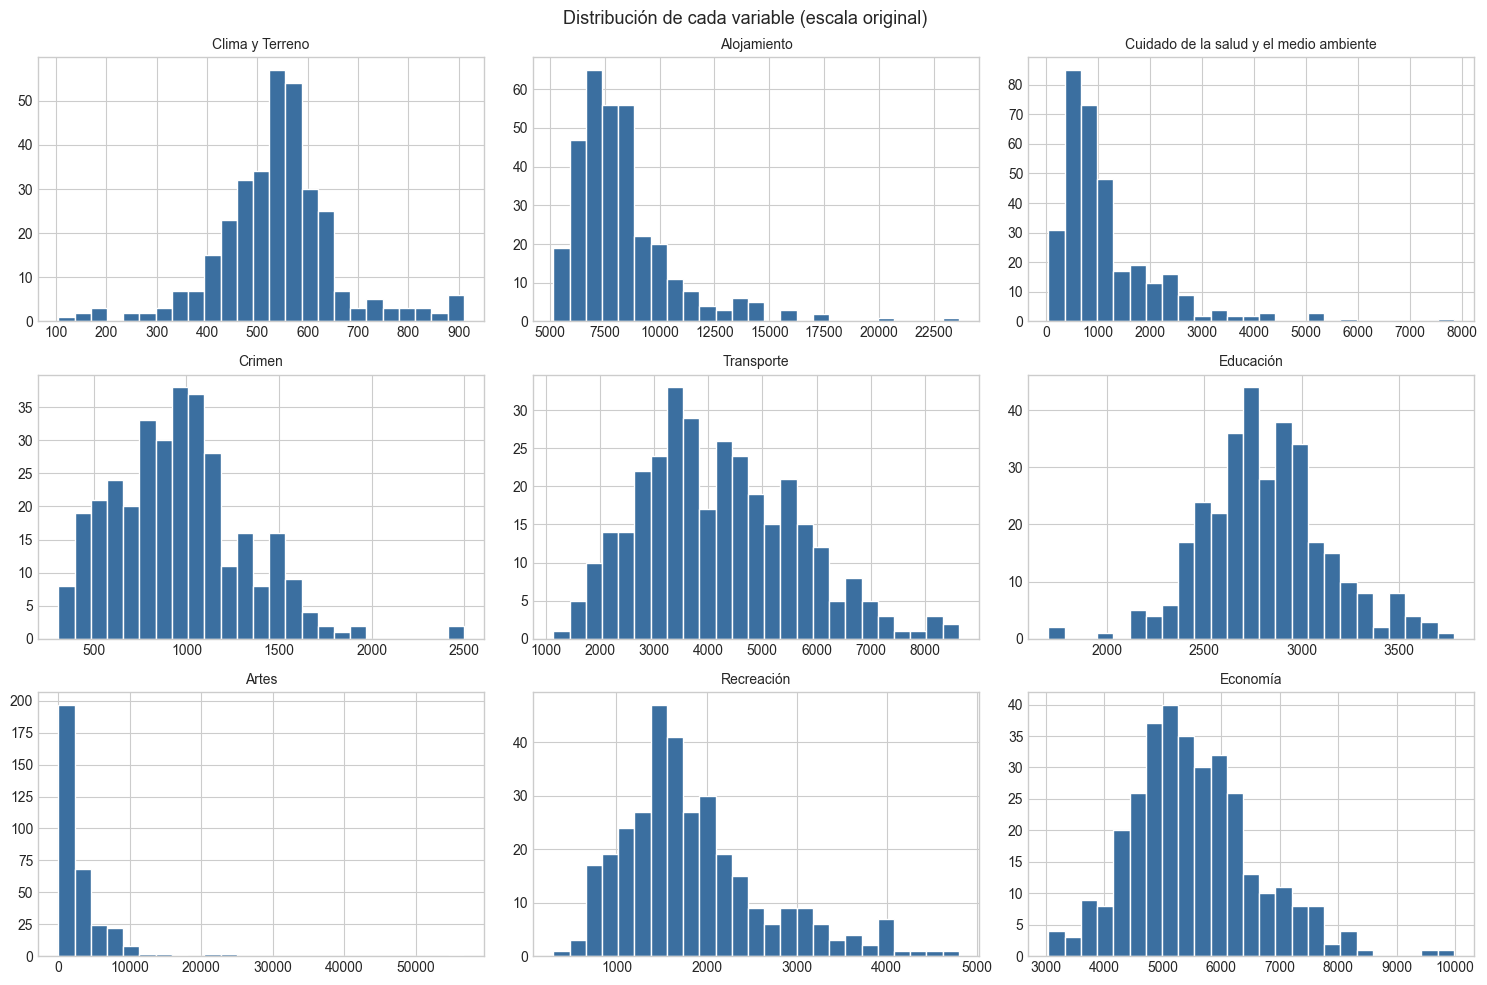

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, df.columns):
    ax.hist(df[col], bins=25, color='#3b6fa0', edgecolor='white')
    ax.set_title(col, fontsize=10)
fig.suptitle('Distribución de cada variable (escala original)', fontsize=13)
plt.tight_layout()
plt.show()

La mayoría de las variables muestran una distribución con cola derecha larga (unas pocas ciudades con puntajes muy altos frente a la mayoría concentrada en valores más bajos o medios). Esto es especialmente visible en *Artes*, *Alojamiento* y *Cuidado de la salud y el medio ambiente*, un patrón consistente con la hipótesis de que unas pocas grandes áreas metropolitanas concentran mucha más oferta cultural, sanitaria y de costo de vida que el resto de las ciudades.

### 1.4 Observaciones atípicas

Estandarizamos únicamente **para fines de comparación visual** (no para el PCA todavía) y marcamos como atípica cualquier observación con normalización $|z| > 3$ en al menos una variable. Siguiendo la guía, **no eliminaremos ninguna observación en esta etapa**: primero identificamos qué ciudades son y qué podría explicar su posición.

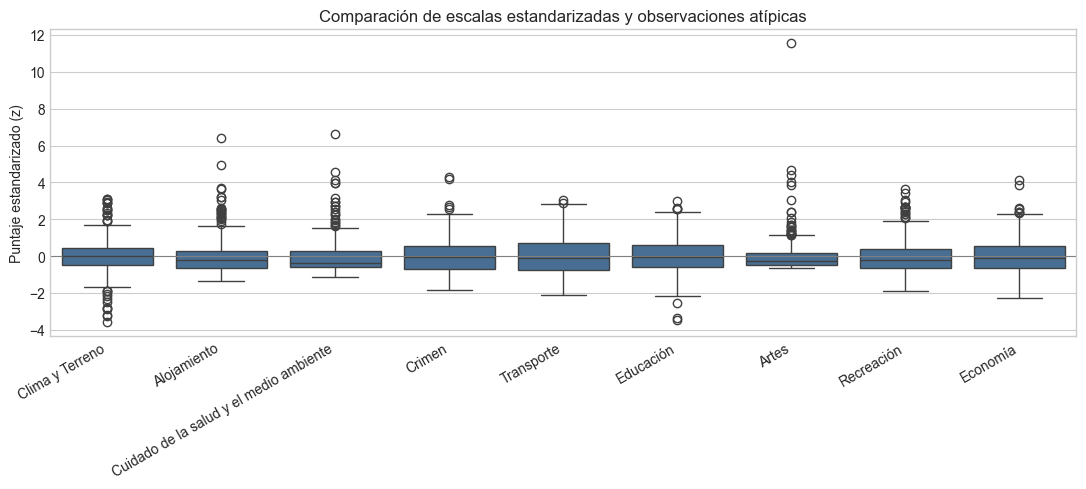

In [8]:
z = (df - df.mean()) / df.std()

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=z, ax=ax, color='#3b6fa0')
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_ylabel('Puntaje estandarizado (z)')
ax.set_title('Comparación de escalas estandarizadas y observaciones atípicas')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [9]:
print("Número de ciudades atípicas (|z|>3) por variable:")
print((z.abs() > 3).sum().sort_values(ascending=False))
print()

for col in df.columns:
    flagged = z.index[z[col].abs() > 3]
    if len(flagged):
        print(f"{col}: {list(flagged)}")

Número de ciudades atípicas (|z|>3) por variable:
Alojamiento                                7
Clima y Terreno                            6
Cuidado de la salud y el medio ambiente    6
Artes                                      6
Educación                                  3
Recreación                                 3
Crimen                                     2
Economía                                   2
Transporte                                 1
dtype: int64

Clima y Terreno: ['Bismarck,ND', 'Fargo-Moorhead,ND-MN', 'Grand-Forks,ND', 'Oakland,CA', 'San-Diego,CA', 'San-Francisco,CA']
Alojamiento: ['Anaheim-Santa-Ana,CA', 'Honolulu,HI', 'Norwalk,CT', 'San-Francisco,CA', 'San-Jose,CA', 'Santa-Barbara-Santa-Maria-Lompoc,CA', 'Stamford,CT']
Cuidado de la salud y el medio ambiente: ['Boston,MA', 'Chicago,IL', 'Los-Angeles,Long-Beach,CA', 'New-York,NY', 'Philadelphia,PA-NJ', 'Washington,DC-MD-VA']
Crimen: ['Miami-Hialeah,FL', 'New-York,NY']
Transporte: ['New-York,NY']
Educación: ['Pascago

Un mismo grupo de grandes áreas metropolitanas. **Nueva York, Chicago, Los Ángeles, Boston, Filadelfia, Washington D.C. y San Francisco**. Reaparecen como atípico en varias variables a la vez (*Cuidado de la salud*, *Artes*, y en el caso de Nueva York también *Crimen* y *Transporte*). Esto refuerza la hipótesis de la sección anterior: no son errores de captura, sino el reflejo esperado de ciudades mucho más grandes y densas que el resto de la muestra. Las mantenemos en el análisis, pero las marcamos para revisar en pasos posteriores, qué tanto influyen sobre el ranking final.

### 1.5 Relaciones entre variables

In [10]:
n_vars = df.shape[1]
n_pairs = comb(n_vars, 2)
print(f"Número de variables: {n_vars}")
print(f"Número de relaciones por pares: C({n_vars},2) = {n_pairs}")

Número de variables: 9
Número de relaciones por pares: C(9,2) = 36


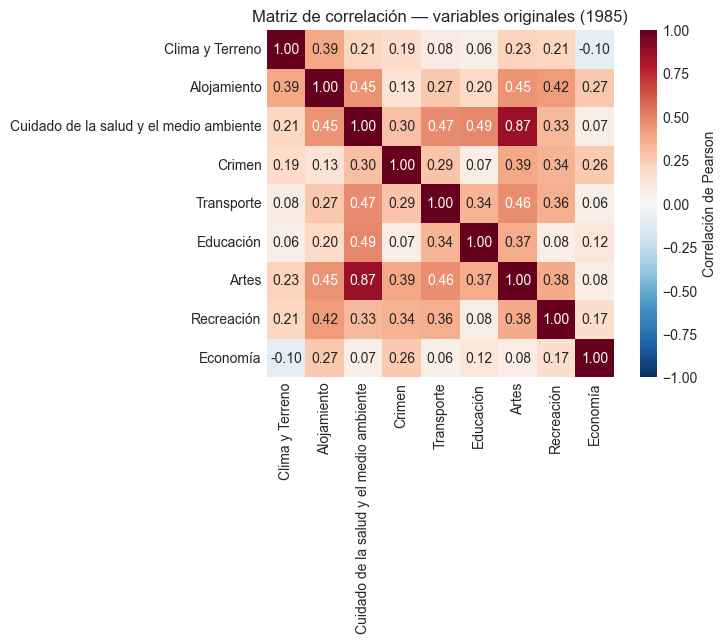

In [11]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'label': 'Correlación de Pearson'})
ax.set_title('Matriz de correlación — variables originales (1985)')
plt.tight_layout()
plt.show()

In [12]:
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pairs = pairs.sort_values(ascending=False)

print("Pares de variables más correlacionados:")
print(pairs.head(6))
print("\nPares de variables menos correlacionados:")
print(pairs.tail(4))

Pares de variables más correlacionados:
Cuidado de la salud y el medio ambiente  Artes                                      0.865796
                                         Educación                                  0.490234
                                         Transporte                                 0.470317
Transporte                               Artes                                      0.464806
Alojamiento                              Cuidado de la salud y el medio ambiente    0.453010
                                         Artes                                      0.448568
dtype: float64

Pares de variables menos correlacionados:
Cuidado de la salud y el medio ambiente  Economía     0.069271
Clima y Terreno                          Educación    0.064520
Transporte                               Economía     0.059247
Clima y Terreno                          Economía    -0.100083
dtype: float64


**¿Qué criterios están más correlacionados y qué hipótesis podrían explicar esas relaciones?**

El par más correlacionado por lejos es **Cuidado de la salud y el medio ambiente y Artes** ($r \approx 0.87$). Le siguen, con correlaciones moderadas ($r \approx 0.42$–$0.49$), *Cuidado de la salud y Educación*, *Cuidado de la salud y Transporte*, *Transporte y Artes* y *Alojamiento y Cuidado de la salud / Artes / Recreación*. En el otro extremo, **Economía** es casi independiente del resto de las variables (correlaciones cercanas a 0, incluso ligeramente negativa con *Clima y Terreno*).

**Hipótesis de trabajo — un factor de "tamaño / densidad metropolitana":** las variables que más covarían (Alojamiento, Salud, Transporte, Artes, Recreación y, en menor medida, Crimen) son precisamente aquellas que tienden a escalar con el tamaño de una ciudad: las áreas metropolitanas grandes concentran más hospitales y oferta cultural, pero también rentas más altas, sistemas de transporte más grandes y más crimen. Esto es coherente con que el mismo grupo de ciudades (Nueva York, Chicago, Boston, Filadelfia, Los Ángeles, Washington D.C.) apareciera como atípico en varias de esas variables en la sección anterior. Si esta hipótesis se confirma en el Paso 3, es probable que el **primer componente principal capture, en buena parte, este eje de tamaño/urbanización**, y no necesariamente el eje de "calidad de vida" que más le interesa al comité — algo que deberemos verificar cuidadosamente al interpretar los componentes.

*Economía* parece responder a una lógica distinta (posiblemente ligada a la estructura productiva local y no al tamaño de la ciudad), por lo que es candidata a formar su propio componente o a cargar débilmente sobre los primeros.

### 1.6 Nota pendiente: dirección de Alojamiento y Crimen

Recordamos, para resolver explícitamente en el **Paso 3**, que en *Alojamiento* y *Crimen* un puntaje **menor** es mejor, mientras que en las siete variables restantes un puntaje **mayor** es mejor. Esta inconsistencia de dirección no afecta el cálculo del PCA en sí (que es puramente una descripción de la varianza y covarianza de los datos), pero sí es crítica para:

1. la **interpretación** de los signos de los *loadings* en cada componente, y
2. la **construcción del índice de atractivo** en el Paso 4, donde todas las variables deberán apuntar consistentemente hacia "mejor = mayor" antes de combinarlas.

Dejamos esta decisión documentada aquí para no tomarla de forma implícita más adelante.

### Cierre del Paso 1 — hallazgos clave

1. Los datos están completos y no requieren limpieza (329 ciudades, 9 variables numéricas, sin nulos ni duplicados).
2. Las variables tienen **escalas muy distintas** (varianzas que difieren en más de 3 órdenes de magnitud) → **es indispensable estandarizar** antes del PCA.
3. Existe un grupo de **grandes áreas metropolitanas** (NY, Chicago, Boston, Filadelfia, LA, Washington D.C., SF) que se comporta como atípico en varias variables simultáneamente — se mantienen en el análisis pero se marcan para el análisis de sensibilidad del Paso 5.
4. La correlación más fuerte (*Salud y Artes*, $r\approx0.87$) y el patrón general de covariación sugieren un posible **factor latente de tamaño/densidad metropolitana**, que deberá contrastarse con la interpretación real de los componentes en el Paso 3.
5. Queda pendiente, y documentada explícitamente, la decisión sobre la **dirección de Alojamiento y Crimen**, a resolver en el Paso 3.

<a id='paso2'></a>
## Paso 2. Cálculo de los componentes principales

### 2.1 Resolviendo la nota pendiente del Paso 1: dirección de Alojamiento y Crimen

Antes de estandarizar, resolvemos explícitamente la nota dejada en la sección 1.6. **Decisión del equipo: invertir el signo de *Alojamiento* y *Crimen*** para que, en las nueve variables, un puntaje más alto sea siempre mejor.

Justificación:

- **Es matemáticamente equivalente** invertir el signo antes o después de estandarizar. Si $y=-x$, entonces $\bar y=-\bar x$ y $s_y=s_x$ (la desviación estándar no cambia porque depende de diferencias al cuadrado), por lo que $z_y=-z_x$. El PCA resultante no cambia en varianza explicada ni en la estructura de los componentes; únicamente cambia el signo del *loading* asociado a estas dos variables.
- Con esta convención, **todos los *loadings* positivos de un componente apuntan hacia "mejor"**, lo que simplifica enormemente la interpretación en el Paso 3 y la construcción del índice de atractivo en el Paso 4, así podremos combinar puntuaciones sin tener que recordar excepciones de signo caso por caso.
- Para dejar la transformación documentada en el propio nombre de la variable, renombramos las columnas invertidas:
  - `Alojamiento` → **Asequibilidad (−Alojamiento)**
  - `Crimen` → **Seguridad (−Crimen)**

A partir de aquí trabajamos con `df_dir`, la versión de los datos con las nueve variables orientadas de forma consistente.

In [13]:
df_dir = df.copy()
df_dir['Alojamiento'] = -df_dir['Alojamiento']
df_dir['Crimen'] = -df_dir['Crimen']
# Renombrar las variables con cambio de dirección
df_dir = df_dir.rename(columns={
    'Alojamiento': 'Asequibilidad (−Alojamiento)',
    'Crimen': 'Seguridad (−Crimen)'
})

print("Verificación: la correlación con la variable original debe ser exactamente -1")
print(f"  Alojamiento vs Asequibilidad: {np.corrcoef(df['Alojamiento'], df_dir['Asequibilidad (−Alojamiento)'])[0, 1]:.4f}")
print(f"  Crimen vs Seguridad:          {np.corrcoef(df['Crimen'], df_dir['Seguridad (−Crimen)'])[0, 1]:.4f}")

df_dir.tail()

Verificación: la correlación con la variable original debe ser exactamente -1
  Alojamiento vs Asequibilidad: -1.0000
  Crimen vs Seguridad:          -1.0000


,Clima y Terreno,Asequibilidad (−Alojamiento),Cuidado de la salud y el medio ambiente,Seguridad (−Crimen),Transporte,Educación,Artes,Recreación,Economía
Ciudad,,,,,,,,,
"Worcester,MA",562,-8715,1805,-680,3643,3299,1784,910,5040
"Yakima,WA",535,-6440,317,-1106,3731,2491,996,2140,4986
"York,PA",540,-8371,713,-440,2267,2903,1022,842,4946
"Youngstown-Warren,OH",570,-7021,1097,-938,3374,2920,2797,1327,3894
"Yuba-City,CA",608,-7875,212,-1179,2768,2387,122,918,4694


### 2.2 Estandarización

Estandarizamos cada variable de `df_dir` para que tenga media 0 y varianza 1:

$$z_{ij} = \frac{x_{ij}-\bar{x_j}}{s_j}$$

Esto evita que el PCA quede dominado por las variables de mayor escala (ver sección 1.2) y hace que la matriz de covarianza de los datos estandarizados coincida con la matriz de correlación de los datos originales.

In [14]:
z = (df_dir - df_dir.mean()) / df_dir.std()

print("Media tras estandarizar (debe ser ~0):")
print(z.mean().round(10))
print("\nDesviación estándar tras estandarizar (debe ser 1):")
print(z.std().round(4))

Media tras estandarizar (debe ser ~0):
Clima y Terreno                            0.0
Asequibilidad (−Alojamiento)              -0.0
Cuidado de la salud y el medio ambiente   -0.0
Seguridad (−Crimen)                       -0.0
Transporte                                -0.0
Educación                                  0.0
Artes                                      0.0
Recreación                                -0.0
Economía                                  -0.0
dtype: float64

Desviación estándar tras estandarizar (debe ser 1):
Clima y Terreno                            1.0
Asequibilidad (−Alojamiento)               1.0
Cuidado de la salud y el medio ambiente    1.0
Seguridad (−Crimen)                        1.0
Transporte                                 1.0
Educación                                  1.0
Artes                                      1.0
Recreación                                 1.0
Economía                                   1.0
dtype: float64


### 2.3 Descomposición espectral (álgebra lineal)

Calculamos los componentes principales "a mano", descomponiendo la matriz de covarianza $S$ de los datos estandarizados en sus eigenvectores (direcciones, columnas de $P$) y eigenvalores (varianza explicada por cada dirección, diagonal de $\Lambda$):

$$S = P\Lambda P'$$

Cada eigenvector $\delta_j$ define un componente $f_j = Z\delta_j'$, y su eigenvalor $\lambda_j$ es exactamente $\text{Var}(f_j)$.

In [15]:
S = z.cov()

eig_val, eig_vec = np.linalg.eig(S.values)

# Ordenamos de mayor a menor varianza explicada
order = np.argsort(eig_val)[::-1]
eig_val = eig_val[order]
eig_vec = eig_vec[:, order]

pc_names = [f'PC{i+1}' for i in range(len(eig_val))]

print("Eigenvalores (varianza explicada por cada componente), de mayor a menor:")
for name, val in zip(pc_names, eig_val):
    print(f"  {name}: {val:.4f}")

Eigenvalores (varianza explicada por cada componente), de mayor a menor:
  PC1: 3.4083
  PC2: 1.2140
  PC3: 1.1415
  PC4: 0.9209
  PC5: 0.7533
  PC6: 0.6306
  PC7: 0.4930
  PC8: 0.3180
  PC9: 0.1204


In [16]:
# Verificamos que S = P Λ P'
S_reconstructed = eig_vec @ np.diag(eig_val) @ eig_vec.T
print("¿Se reconstruye S = P Λ P' correctamente?", np.allclose(S.values, S_reconstructed))

loadings = pd.DataFrame(eig_vec, index=z.columns, columns=pc_names)
loadings.round(3)
# print((loadings**2).sum())

¿Se reconstruye S = P Λ P' correctamente? True


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Clima y Terreno,0.206,-0.218,0.690,-0.137,-0.369,-0.375,0.085,0.362,0.001
Asequibilidad (−Alojamiento),-0.357,0.251,-0.208,0.512,-0.233,-0.142,-0.231,0.614,-0.014
Cuidado de la salud y el medio ambiente,0.460,0.299,0.007,-0.015,-0.103,0.374,-0.014,0.186,-0.716
Seguridad (−Crimen),-0.281,0.355,0.185,-0.539,0.524,0.081,0.019,0.430,0.059
Transporte,0.351,0.180,-0.146,0.303,0.404,-0.468,0.583,0.094,0.004
Educación,0.275,0.483,-0.230,-0.335,-0.209,-0.502,-0.426,-0.189,0.111
Artes,0.463,0.195,0.026,0.101,-0.105,0.462,0.022,0.204,0.686
Recreación,0.328,-0.384,0.051,0.190,0.530,-0.090,-0.628,0.151,-0.026
Economía,0.135,-0.471,-0.607,-0.422,-0.160,-0.033,0.150,0.405,0.000


In [17]:
# Puntuaciones de cada ciudad en cada componente: F = Z · P
scores_manual = pd.DataFrame(z.values @ eig_vec, index=z.index, columns=pc_names)
scores_manual.tail()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Ciudad,,,,,,,,,
"Worcester,MA",-0.140983,1.642143,0.230877,-1.224202,-0.670711,-0.348114,-0.159054,-0.309008,-0.400504
"Yakima,WA",-1.132624,-0.739830,0.319330,1.115428,0.099816,-0.027811,-0.257803,0.062502,0.144835
"York,PA",-1.708201,0.904933,0.657982,-1.340779,-0.311793,0.344883,-0.170877,-0.136739,0.165862
"Youngstown-Warren,OH",-0.765311,1.075326,0.962153,0.435825,-0.575757,-0.027063,-0.403151,-0.390747,0.057641
"Yuba-City,CA",-1.725960,-0.730340,1.076105,0.551422,-1.017898,0.306287,0.586163,-0.571341,0.087884


### 2.4 Validación con `sklearn`

Repetimos el cálculo con `sklearn.decomposition.PCA` sobre los datos ya estandarizados en `z` (no usamos `StandardScaler` porque volvería a estandarizar con `ddof=0`, mientras que `z.cov()` usa `ddof=1`; alimentar `z` directamente evita esa discrepancia decimal y permite comparar cifra a cifra). Los *loadings* deberían coincidir en magnitud —posiblemente con signo opuesto, ya que el signo de un componente es arbitrario (ver contexto teórico)—.

In [18]:
from sklearn.decomposition import PCA

pca = PCA()
scores_sklearn = pd.DataFrame(pca.fit_transform(z), index=z.index, columns=pc_names)
loadings_sklearn = pd.DataFrame(pca.components_.T, index=z.columns, columns=pc_names)

print("¿Coinciden los eigenvalores manuales con pca.explained_variance_?",
      np.allclose(eig_val, pca.explained_variance_, atol=1e-6))
print("¿Coinciden los loadings en magnitud (con signo posiblemente distinto)?",
      np.allclose(loadings.abs().values, loadings_sklearn.abs().values, atol=1e-6))
print("¿Coinciden las puntuaciones en magnitud (con signo posiblemente distinto)?",
      np.allclose(scores_manual.abs().values, scores_sklearn.abs().values, atol=1e-6))

¿Coinciden los eigenvalores manuales con pca.explained_variance_? True
¿Coinciden los loadings en magnitud (con signo posiblemente distinto)? True
¿Coinciden las puntuaciones en magnitud (con signo posiblemente distinto)? True


### 2.5 Selección del número de componentes

Aplicamos los tres criterios discutidos en la teoría (scree plot, proporción de varianza acumulada y criterio de Kaiser) sobre los mismos 9 eigenvalores.

In [19]:
evr = eig_val / eig_val.sum()
cum_evr = np.cumsum(evr)

resumen = pd.DataFrame({
    'Eigenvalor': eig_val,
    'Prop. Varianza Explicada': evr,
    'Prop. Varianza Acumulada': cum_evr
}, index=pc_names)
resumen.round(4)

,Eigenvalor,Prop. Varianza Explicada,Prop. Varianza Acumulada
PC1,3.4083,0.3787,0.3787
PC2,1.2140,0.1349,0.5136
PC3,1.1415,0.1268,0.6404
PC4,0.9209,0.1023,0.7427
PC5,0.7533,0.0837,0.8264
PC6,0.6306,0.0701,0.8965
PC7,0.4930,0.0548,0.9513
PC8,0.3180,0.0353,0.9866
PC9,0.1204,0.0134,1.0000


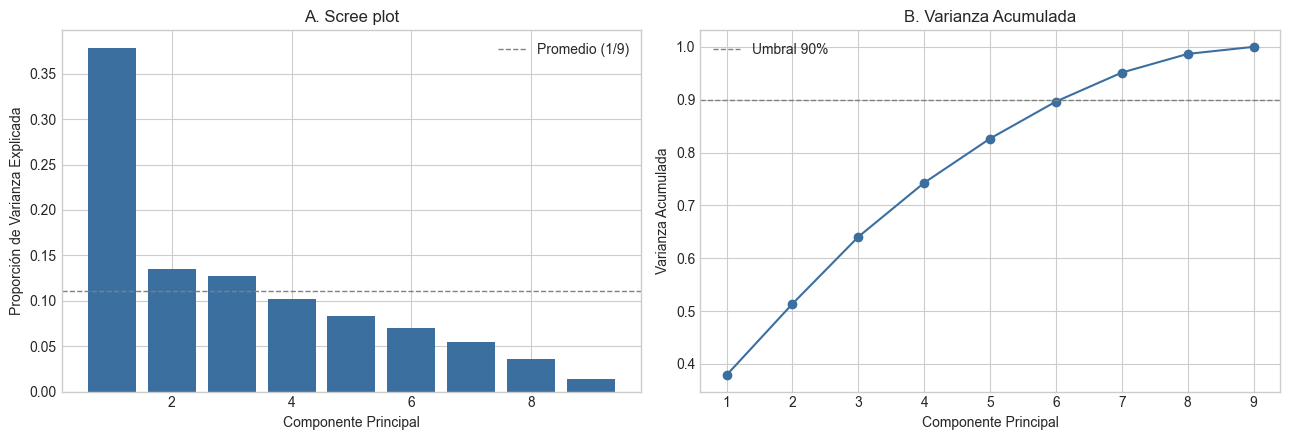

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(1, len(eig_val) + 1), evr, color='#3b6fa0')
axes[0].axhline(1 / len(eig_val), color='grey', linestyle='--', linewidth=1,
                 label=f'Promedio (1/{len(eig_val)})')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Proporción de Varianza Explicada')
axes[0].set_title('A. Scree plot')
axes[0].legend()

axes[1].plot(range(1, len(eig_val) + 1), cum_evr, marker='o', color='#3b6fa0')
axes[1].axhline(0.9, color='grey', linestyle='--', linewidth=1, label='Umbral 90%')
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].set_title('B. Varianza Acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
n_kaiser = int((eig_val > 1).sum())
print(f"Criterio de Kaiser (eigenvalor > 1): {n_kaiser} componentes")
print(eig_val.round(3))

Criterio de Kaiser (eigenvalor > 1): 3 componentes
[3.408 1.214 1.141 0.921 0.753 0.631 0.493 0.318 0.12 ]


**Lectura de los tres criterios (con las 9 variables ya orientadas "mayor = mejor"):**

| Criterio | Resultado |
|---|---|
| Scree plot | Caída pronunciada de PC1 (3.41) a PC2 (1.21); luego una meseta casi plana entre PC2 y PC3 (1.21 → 1.14) antes de otra caída hacia PC4 (0.92). El codo más defendible está **entre PC3 y PC4**. |
| Varianza acumulada | 3 componentes explican **64.0%**; se necesitan 4 para superar el umbral típico de 70% (74.3%) y 7 para superar 90% (95.1%). |
| Kaiser ($\lambda>1$) | Retiene **3 componentes** (PC1=3.41, PC2=1.21, PC3=1.14); PC4 queda apenas debajo (0.92). |

**Decisión: retenemos 3 componentes principales (PC1–PC3).**

Los tres criterios apuntan de forma consistente a un rango entre 3 y 4 componentes, con PC3 y PC4 muy cerca del umbral (1.14 vs. 0.92) — es una frontera genuinamente ambigua, no un caso de manual donde un criterio gane con claridad. Nos quedamos con 3 porque:

1. Es el resultado del criterio de Kaiser, el más objetivo de los tres (no depende de un umbral arbitrario elegido a priori).
2. El 64% de varianza acumulada es razonable para un primer filtro cuantitativo — no buscamos reconstruir los datos originales, sino encontrar los ejes más informativos para diferenciar ciudades.
3. Como veremos en el Paso 3, cada uno de los tres primeros componentes admite una interpretación temática clara, mientras que a partir de PC4 los *loadings* se vuelven más difusos y difíciles de nombrar con confianza.

Dado lo cerrado de la frontera entre 3 y 4 componentes, **usar 4 componentes en lugar de 3 queda registrado como una de las variaciones metodológicas a probar en el análisis de sensibilidad del Paso 5** (tal como sugiere la guía: *"utilizar uno o varios componentes"*).

### Cierre del Paso 2 — hallazgos clave

1. Se resolvió la nota pendiente del Paso 1: **Alojamiento y Crimen quedaron invertidos** (`Asequibilidad`, `Seguridad`) para que las 9 variables compartan la dirección "mayor = mejor".
2. El PCA calculado por álgebra lineal (eigendescomposición de $S$) y por `sklearn` **coinciden exactamente** en eigenvalores, *loadings* (en magnitud) y puntuaciones.
3. Retenemos **3 componentes principales**, que explican el **64.0%** de la varianza total, por criterio de Kaiser y por interpretabilidad (a confirmar en el Paso 3).
4. Queda documentada la alternativa de **4 componentes** como variación a probar en el análisis de sensibilidad del Paso 5.

<a id='paso3'></a>
## Paso 3. Interpretación de los componentes

Trabajamos con los tres componentes retenidos en el Paso 2 (PC1, PC2 y PC3, 64.0% de la varianza total). Como las nueve variables ya quedaron orientadas para que mayor sea siempre mejor, un loading positivo en un componente empuja ese componente hacia mejor en esa variable, y uno negativo lo empuja hacia peor.

Para cada componente miramos dos cosas: qué variables cargan más fuerte y en qué dirección, y qué ciudades obtienen las puntuaciones más altas y más bajas. Recordamos que el signo global de un componente es arbitrario, lo relevante es la relación entre los signos de las variables.

In [22]:
loadings_3 = loadings[['PC1', 'PC2', 'PC3']].round(3)
loadings_3

,PC1,PC2,PC3
Clima y Terreno,0.206,-0.218,0.690
Asequibilidad (−Alojamiento),-0.357,0.251,-0.208
Cuidado de la salud y el medio ambiente,0.460,0.299,0.007
Seguridad (−Crimen),-0.281,0.355,0.185
Transporte,0.351,0.180,-0.146
Educación,0.275,0.483,-0.230
Artes,0.463,0.195,0.026
Recreación,0.328,-0.384,0.051
Economía,0.135,-0.471,-0.607


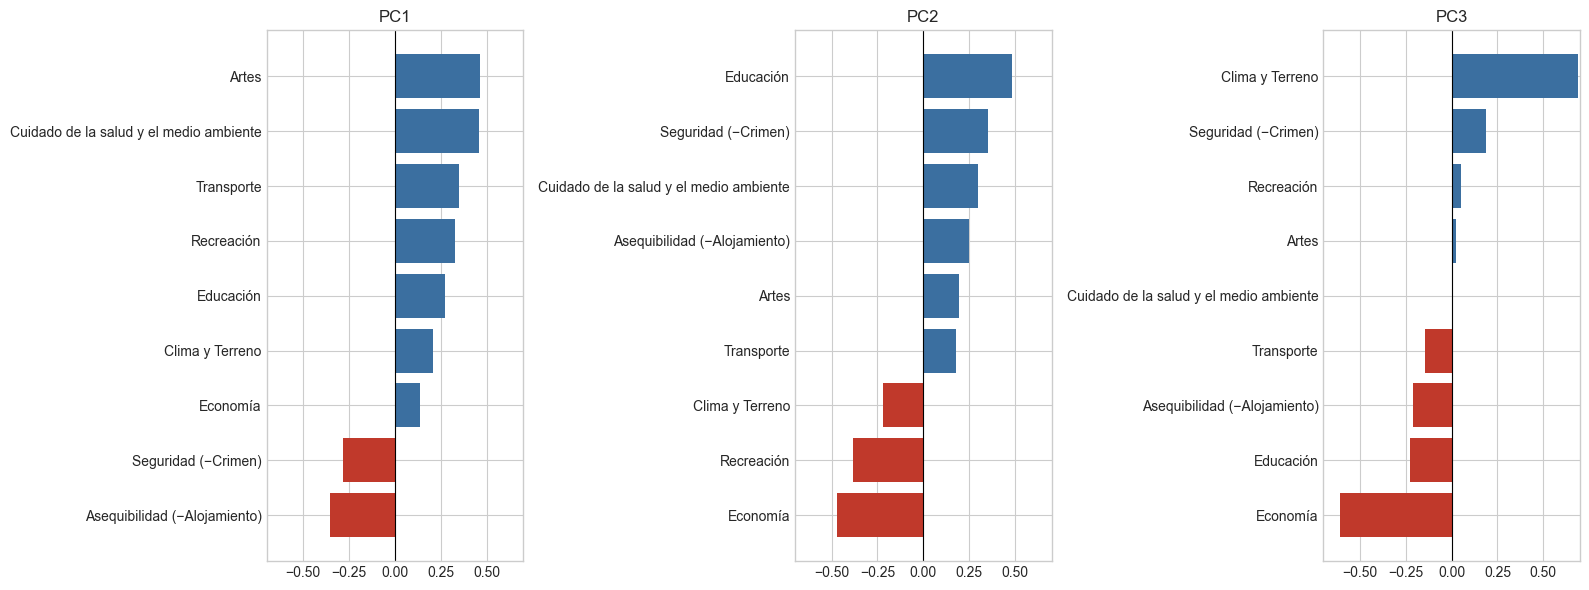

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, pc in zip(axes, ['PC1', 'PC2', 'PC3']):
    vals = loadings[pc].sort_values()
    colors = ['#c0392b' if v < 0 else '#3b6fa0' for v in vals]
    ax.barh(vals.index, vals.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(pc)
    ax.set_xlim(-0.7, 0.7)
plt.tight_layout()
plt.show()

In [24]:
def top_bottom(pc, n=5):
    top = scores_manual[pc].sort_values(ascending=False).head(n)
    bottom = scores_manual[pc].sort_values(ascending=True).head(n)
    tabla = pd.DataFrame({
        'Ciudad con puntuación alta': top.index,
        'Puntuación alta': top.values.round(2),
        'Ciudad con puntuación baja': bottom.index,
        'Puntuación baja': bottom.values.round(2)
    })
    return tabla

### PC1. Escala metropolitana

Los loadings positivos más altos son Artes (0.46), Cuidado de la salud y el medio ambiente (0.46), Transporte (0.35) y Recreación (0.33). Los dos loadings negativos son Asequibilidad (-0.36) y Seguridad (-0.28).

Las ciudades con puntuación más alta son Nueva York, San Francisco, Los Ángeles, Chicago y Boston, es decir, exactamente las grandes áreas metropolitanas marcadas como atípicas en el Paso 1. Las de puntuación más baja son ciudades pequeñas del sur y del cinturón industrial como Gadsden, Dothan, Pascagoula, Florence y McAllen.

Esto confirma la hipótesis planteada en el Paso 1. PC1 mide el tamaño y la oferta de una ciudad. Las ciudades grandes ofrecen más salud, cultura, transporte y recreación, pero a cambio de vivienda menos asequible y menos seguridad. Nombramos este componente Escala metropolitana.

In [25]:
top_bottom('PC1')

,Ciudad con puntuación alta,Puntuación alta,Ciudad con puntuación baja,Puntuación baja
0,"New-York,NY",12.43,"Gadsden,AL",-2.92
1,"San-Francisco,CA",7.39,"Dothgan,AL",-2.79
2,"Los-Angeles,Long-Beach,CA",7.25,"Pascagoula,MS",-2.73
3,"Chicago,IL",6.46,"Florence,AL",-2.65
4,"Boston,MA",6.30,"McAllen-Edinburg-Mission,TX",-2.57


### PC2. Solidez institucional frente a dinamismo económico

Los loadings positivos más altos son Educación (0.48), Seguridad (0.36), Cuidado de la salud (0.30) y Asequibilidad (0.25). Los negativos son Economía (-0.47), Recreación (-0.38) y Clima y Terreno (-0.22).

Las ciudades con puntuación más alta son Chicago, Filadelfia, Pittsburgh, Washington D.C. y Nueva York, ciudades del noreste y del cinturón industrial con instituciones educativas y sistemas de seguridad consolidados. Las de puntuación más baja son Las Vegas, Atlantic City, Midland, Salinas Seaside Monterey y Lafayette, economías de auge ligadas al turismo, el entretenimiento o la energía, con clima favorable y fuerte actividad económica.

Vale la pena notar algo que separa a PC2 de PC1. Nueva York, Chicago, Filadelfia y Washington D.C. puntúan alto en ambos componentes, son grandes y además institucionalmente sólidas. San Francisco y Los Ángeles, en cambio, puntúan alto en PC1 pero negativo en PC2 (San Francisco en -1.23 y Los Ángeles en -0.48), es decir son grandes ciudades con un perfil económico más parecido al de las ciudades de auge que al de las ciudades industriales.

Nombramos este componente Solidez institucional frente a dinamismo económico.

In [26]:
top_bottom('PC2')

,Ciudad con puntuación alta,Puntuación alta,Ciudad con puntuación baja,Puntuación baja
0,"Chicago,IL",3.09,"Las-Vegas,NV",-3.34
1,"Philadelphia,PA-NJ",3.07,"Atlantic-City,NJ",-3.05
2,"Pittsburgh,PA",2.46,"Midland,TX",-3.03
3,"Washington,DC-MD-VA",2.26,"Salinas-Seaside-Monterey,CA",-2.87
4,"New-York,NY",2.06,"Lafayette,LA",-2.54


### PC3. Clima frente a economía

Este componente es el más simple de los tres. Casi todo su peso está en dos variables: Clima y Terreno (0.69) y Economía (-0.61). El resto de los loadings son cercanos a cero.

Las ciudades con puntuación más alta son Oxnard Ventura, San Diego, Eugene Springfield, Santa Cruz y Salinas Seaside Monterey, todas de la costa oeste con clima templado durante todo el año. Las de puntuación más baja son Lafayette, Anchorage, Grand Forks, Bryan College Station y Ocala, ciudades con clima extremo, frío en Dakota del Norte y Alaska, calor húmedo en Luisiana, Texas y Florida, pero con economías locales fuertes, varias ligadas a energía y agricultura.

PC3 contrapone confort climático contra fortaleza económica local. Nombramos este componente Clima frente a economía.

In [27]:
top_bottom('PC3')

,Ciudad con puntuación alta,Puntuación alta,Ciudad con puntuación baja,Puntuación baja
0,"Oxnard-Ventura,CA",3.28,"Lafayette,LA",-2.74
1,"San-Diego,CA",2.59,"Anchorage,AK",-2.70
2,"Eugene-Springfield,OR",2.44,"Grand-Forks,ND",-2.41
3,"Santa-Cruz,CA",2.42,"Bryan-College-Station,TX",-2.32
4,"Salinas-Seaside-Monterey,CA",2.41,"Ocala,FL",-2.30


### Biplot PC1 y PC2

El biplot muestra a la vez las 329 ciudades (puntos, según sus puntuaciones) y las 9 variables (flechas, según sus loadings) sobre el plano de los dos componentes con mayor varianza explicada.

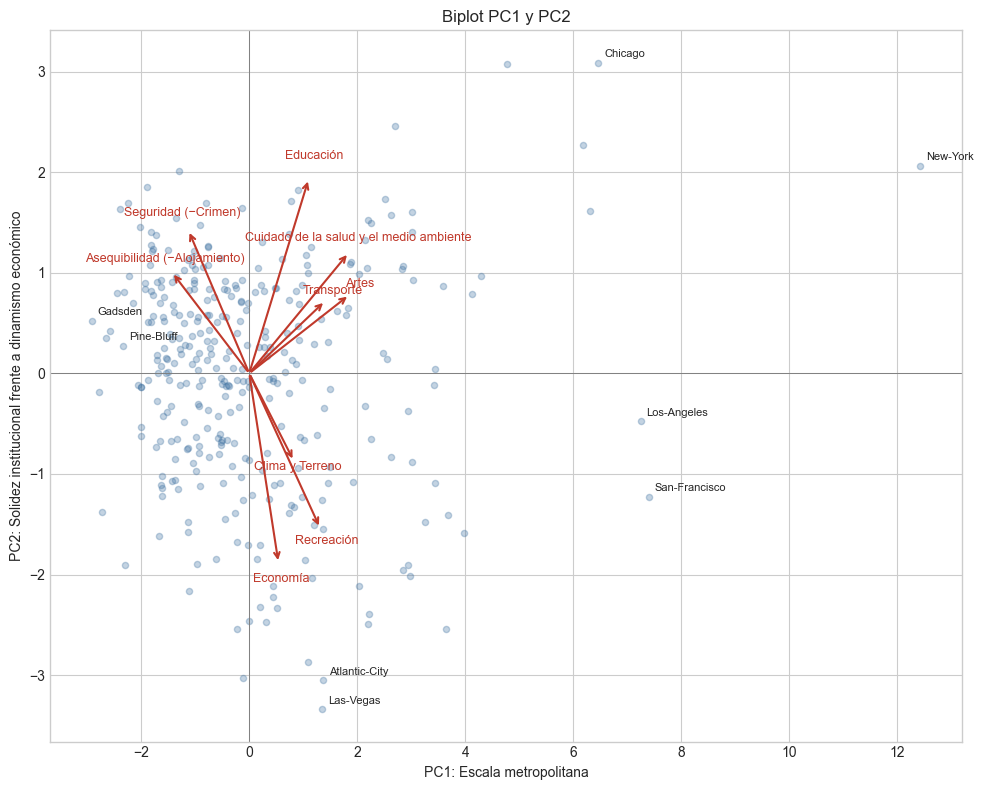

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(scores_manual['PC1'], scores_manual['PC2'], alpha=0.3, color='#3b6fa0', s=20)

scale = 4
for var in loadings.index:
    x, y = loadings.loc[var, 'PC1'] * scale, loadings.loc[var, 'PC2'] * scale
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#c0392b', linewidth=1.5))
    ax.text(x * 1.1, y * 1.1, var, fontsize=9, color='#c0392b', ha='center')

destacadas = ['New-York,NY', 'San-Francisco,CA', 'Los-Angeles,Long-Beach,CA', 'Chicago,IL',
              'Las-Vegas,NV', 'Atlantic-City,NJ', 'Gadsden,AL', 'Pine-Bluff,AR']
for c in destacadas:
    x, y = scores_manual.loc[c, 'PC1'], scores_manual.loc[c, 'PC2']
    ax.annotate(c.split(',')[0], (x, y), fontsize=8, xytext=(4, 4), textcoords='offset points')

ax.axhline(0, color='grey', linewidth=0.7)
ax.axvline(0, color='grey', linewidth=0.7)
ax.set_xlabel('PC1: Escala metropolitana')
ax.set_ylabel('PC2: Solidez institucional frente a dinamismo económico')
ax.set_title('Biplot PC1 y PC2')
plt.tight_layout()
plt.show()

### Cierre del Paso 3. hallazgos clave

| Componente | Nombre | Varianza explicada | Variables dominantes |
|---|---|---|---|
| PC1 | Escala metropolitana | 37.9% | Artes, Salud, Transporte, Recreación (positivo). Asequibilidad, Seguridad (negativo) |
| PC2 | Solidez institucional frente a dinamismo económico | 13.5% | Educación, Seguridad, Salud (positivo). Economía, Recreación, Clima (negativo) |
| PC3 | Clima frente a economía | 12.7% | Clima y Terreno (positivo). Economía (negativo) |

Tres ideas para llevar al Paso 4.

1. PC1 confirma con datos la hipótesis de tamaño y densidad metropolitana planteada en el Paso 1. No mide calidad de vida en general, mide oferta urbana a cambio de asequibilidad y seguridad, lo que implica un trade off real, no un defecto del componente.
2. PC1 y PC2 son independientes por construcción, pero no siempre se mueven igual entre las ciudades grandes. Nueva York, Chicago, Filadelfia y Washington D.C. combinan tamaño con solidez institucional. San Francisco y Los Ángeles combinan tamaño con un perfil económico más parecido al de las ciudades de auge.
3. PC3 aporta una dimensión casi ortogonal a las otras dos, prácticamente reducida a clima contra economía, y será relevante para ciudades que no destacan en tamaño ni en solidez institucional pero sí en confort climático.

Con estos tres componentes nombrados y con evidencia de qué ciudades representa cada extremo, en el Paso 4 construimos el índice de atractivo y el ranking de las 329 ciudades.

<a id='paso4'></a>
## Paso 4. Construcción del índice y del ranking

En el Paso 3 nombramos tres componentes. Escala metropolitana, Solidez institucional frente a dinamismo económico y Clima frente a economía. Ninguno de los tres es, por sí solo, una medida de atractivo. Cada uno mezcla variables que suman puntos con variables que restan puntos. En este paso los combinamos en un único índice de atractivo relativo, documentando cada decisión.

### 4.1 Puntuaciones en una escala comparable

El eigenvalor de PC1 (3.41) es casi tres veces el de PC2 (1.21) y de PC3 (1.14), así que la varianza de las puntuaciones de PC1 también es casi tres veces mayor. Si combinamos las puntuaciones tal cual, cualquier peso que asignemos quedaría dominado por la escala natural de PC1, no por la importancia que nosotros le queramos dar. Por eso, antes de ponderar, llevamos cada componente a varianza 1.

In [29]:
scores_std = scores_manual[['PC1', 'PC2', 'PC3']] / scores_manual[['PC1', 'PC2', 'PC3']].std()

print("Desviación estándar tras reescalar (debe ser 1):")
print(scores_std.std().round(4))

Desviación estándar tras reescalar (debe ser 1):
PC1    1.0
PC2    1.0
PC3    1.0
dtype: float64


### 4.2 Primer intento. pesos proporcionales a la varianza explicada

Lo normal sería ponderar cada componente según cuánta varianza explica. PC1 explica 37.9% de la varianza total, así que dentro de los tres componentes retenidos le correspondería un peso de 0.591, contra 0.211 de PC2 y 0.198 de PC3.
$$ Índice=w_1​⋅PC1+w_2​⋅PC2+w_3​⋅PC3 $$

Antes de intentar aplicar estos pesos conviene hacer una prueba de coherencia. Como cada componente es una combinación lineal de las nueve variables originales, cualquier combinación de PC1, PC2 y PC3, por o tanto se puede decir que es equivalente a asignar un peso implícito a cada una de las nueve variables. Calculamos esos pesos implícitos y verificamos si tienen sentido de negocio, es decir, si todos apuntan en la dirección de mayor es mejor.

$$x_i = \sum^{3}_{j=1}w_j⋅\delta_{ij}$$

In [30]:
def pesos_implicitos(pesos_pc):
    # pesos_pc: dict como {'PC1': w1, 'PC2': w2, 'PC3': w3}, sobre las puntuaciones ya estandarizadas
    a = pd.Series({pc: w / scores_manual[pc].std() for pc, w in pesos_pc.items()})
    implicitos = (loadings[list(pesos_pc)] * a).sum(axis=1)
    return implicitos.sort_values(ascending=False)

pesos_varianza = {'PC1': 0.591, 'PC2': 0.211, 'PC3': 0.198}

print("Pesos implícitos sobre las nueve variables originales (pesos por varianza explicada):")
print(pesos_implicitos(pesos_varianza).round(3))

Pesos implícitos sobre las nueve variables originales (pesos por varianza explicada):
Cuidado de la salud y el medio ambiente    0.206
Artes                                      0.190
Clima y Terreno                            0.152
Educación                                  0.138
Transporte                                 0.120
Recreación                                 0.041
Seguridad (−Crimen)                        0.012
Asequibilidad (−Alojamiento)              -0.105
Economía                                  -0.159
dtype: float64


In [31]:
indice_naive = sum(w * scores_std[pc] for pc, w in pesos_varianza.items())
print("Top 10 con pesos por varianza explicada:")
print(indice_naive.sort_values(ascending=False).head(10).round(3))

Top 10 con pesos por varianza explicada:
Ciudad
New-York,NY                  4.412
Los-Angeles,Long-Beach,CA    2.608
Chicago,IL                   2.588
San-Francisco,CA             2.445
Washington,DC-MD-VA          2.345
Boston,MA                    2.258
Philadelphia,PA-NJ           2.051
Newark,NJ                    1.526
Baltimore,MD                 1.408
San-Diego,CA                 1.386
dtype: float64


El resultado confirma la advertencia de la guía. La proporción de varianza explicada describe la estructura de los datos, no la importancia que el comité debería otorgar a cada dimensión. Con estos pesos, Asequibilidad recibe un peso implícito de -0.105 y Economía de -0.159. En otras palabras, este índice premia a las ciudades menos asequibles y con economía local más débil, justo lo contrario de lo que le interesa a la empresa. El top 10 queda dominado únicamente por las metrópolis más grandes y caras, Nueva York, Los Ángeles, Chicago, San Francisco, Washington D.C., sin ningún criterio de negocio detrás, solo el tamaño de PC1. Descartamos este esquema y construimos uno con pesos definidos por criterio de negocio.

### 4.3 Un límite que conviene conocer antes de elegir pesos

Antes de proponer un esquema alternativo probamos algo más ambicioso. Buscamos si existe alguna combinación de PC1, PC2 y PC3, con cualquier peso, que produzca pesos implícitos no negativos en las nueve variables a la vez. Si existiera, evitaríamos por completo el problema anterior.

In [32]:
from scipy.optimize import linprog

L = loadings[['PC1', 'PC2', 'PC3']].values  # 9x3

# Buscamos a tal que L @ a sea mayor o igual a un pequeño umbral positivo en las 9 variables
A_ub = -L
# Comprobar si todos los pesos implícitos con >= 0 testeando com el umbral de 0
b_ub = -0.01 * np.ones(L.shape[0])
resultado = linprog(c=[0, 0, 0], A_ub=A_ub, b_ub=b_ub, bounds=[(-10, 10)] * 3, method='highs')

print("¿Existe una combinación de PC1, PC2 y PC3 con pesos implícitos no negativos en las nueve variables?",
      resultado.success)

¿Existe una combinación de PC1, PC2 y PC3 con pesos implícitos no negativos en las nueve variables? False


No existe tal combinación. La prueba de factibilidad confirma que, con los tres componentes retenidos, no hay ningún esquema de pesos ($𝑤_1$, $𝑤_2$, $𝑤_3$) que produzca un índice favorable a las nueve variables originales simultáneamente. Esto no es una limitación del método ni un error de especificación, es información real sobre la estructura de las ciudades evaluadas en 1985: dentro del espacio definido por PC1-PC3, Asequibilidad y Economía se oponen sistemáticamente a Escala metropolitana y Solidez institucional (ya visible en el biplot de la sección 3, donde sus loadings apuntan en direcciones casi opuestas). En otras palabras, las ciudades más asequibles y económicamente dinámicas de la muestra tienden a ser, en promedio, las de menor escala metropolitana y menor solidez institucional — y viceversa.

Esto convierte la construcción del índice en una decisión explícita de a quién beneficia el criterio de selección, no en un ejercicio puramente estadístico. El "primer intento" (ponderar por varianza explicada) tomó esa decisión implícitamente y sin advertirlo: penalizó Asequibilidad (−0.105) y Economía (−0.159) como efecto colateral de un criterio que no tenía en cuenta el signo de negocio de cada variable.

De acá en adelante, cualquier esquema de pesos que propongamos va a sacrificar necesariamente alguna de las nueve variables. La pregunta relevante ya no es "¿qué pesos son estadísticamente correctos?" ya nos dimos cuenta que no existe tal cosa, sino "¿qué trade-off es defendible frente al comité, dado que la empresa busca reubicar 500 empleados y sus familias?". Tres alternativas razonables, que evaluaremos en el análisis de sensibilidad:

- Priorizar habitabilidad para las familias (Asequibilidad, Seguridad, Clima) — coherente con que gran parte de los empleados se trasladará con sus familias, aceptando el costo en Escala metropolitana/Economía.
- Priorizar solidez institucional y de infraestructura (Educación, Salud, Transporte) — apuesta a sostenibilidad de largo plazo de la sede, aceptando el costo en Asequibilidad.
- Ponderación equitativa explícita, con pesos iguales o casi iguales entre PC1-PC3, documentando y aceptando abiertamente que Asequibilidad/Economía quedarán relativamente subponderadas frente a Escala/Solidez.

Cualquiera de las tres es una decisión de negocio válida — lo que ya no es aceptable, tras esta prueba, es elegir pesos sin declarar cuál de estos trade-offs se está asumiendo.
### 4.4 Pesos por criterio de negocio

La empresa necesita tres cosas de la nueva sede. Suficiente escala para reclutar 500 empleados y ofrecerles servicios (Escala metropolitana). Buenas escuelas y seguridad para las familias que se trasladen (Solidez institucional). Un clima razonable como factor secundario de calidad de vida (Clima frente a economía).

Con ese orden de prioridad asignamos los pesos:

- PC1, Escala metropolitana. 0.35
- PC2, Solidez institucional frente a dinamismo económico. 0.45
- PC3, Clima frente a economía. 0.20

Le damos el peso más alto a PC2 y no a PC1 por una razón concreta. El Paso 3 mostró que llevar PC1 al extremo desemboca en ciudades como Nueva York, con vivienda carísima y menos seguridad. Para una sede que debe atraer y retener talento con familias, priorizamos primero la solidez institucional (educación y seguridad) y dejamos que la escala metropolitana aporte tamaño de mercado laboral sin ser el criterio dominante. El clima entra como desempate, con el peso más bajo de los tres.

In [33]:
pesos_negocio = {'PC1': 0.35, 'PC2': 0.45, 'PC3': 0.20}

print("Pesos implícitos sobre las nueve variables originales (pesos por criterio de negocio):")
print(pesos_implicitos(pesos_negocio).round(3))

Pesos implícitos sobre las nueve variables originales (pesos por criterio de negocio):
Cuidado de la salud y el medio ambiente    0.211
Educación                                  0.207
Artes                                      0.172
Seguridad (−Crimen)                        0.126
Transporte                                 0.113
Clima y Terreno                            0.079
Asequibilidad (−Alojamiento)              -0.004
Recreación                                -0.085
Economía                                  -0.280
dtype: float64


Es una mejora clara frente al primer intento. Asequibilidad pasa de -0.105 a -0.004, prácticamente neutral. Seguridad, Educación, Salud, Artes, Transporte y Clima quedan con peso positivo. Solo dos variables mantienen peso implícito negativo, Recreación con -0.085 y Economía con -0.280.

Aceptamos ese costo de forma explícita. Preferimos que el índice reste algo de puntos por debilidad económica local y por menor oferta recreativa antes que restar puntos por vivienda cara, que es el costo directo para la empresa y sus empleados. Queda como limitación documentada. La fase de due diligence deberá revisar por separado la fortaleza económica de las finalistas usando la variable Economía original, no solo el índice compuesto.

### 4.5 Índice de atractivo y ranking completo

El índice de atractivo de cada ciudad es la suma ponderada de sus tres puntuaciones estandarizadas.

$$\text{Índice} = 0.35 \cdot PC1_{std} + 0.45 \cdot PC2_{std} + 0.20 \cdot PC3_{std}$$

In [34]:
indice = sum(w * scores_std[pc] for pc, w in pesos_negocio.items())

ranking = pd.DataFrame({'Índice': indice}).sort_values('Índice', ascending=False)
ranking.insert(0, 'Posición', range(1, len(ranking) + 1))

ranking.to_csv('ranking_ciudades.csv')
print(f"Ranking completo guardado en ranking_ciudades.csv ({len(ranking)} ciudades).")
ranking.round(3)

Ranking completo guardado en ranking_ciudades.csv (329 ciudades).


,Posición,Índice
Ciudad,,
"New-York,NY",1,3.237
"Chicago,IL",2,2.413
"Philadelphia,PA-NJ",3,2.095
"Washington,DC-MD-VA",4,2.028
"Boston,MA",5,1.784
...,...,...
"Atlantic-City,NJ",325,-1.215
"Houma-Thibodaux,LA",326,-1.244
"Anchorage,AK",327,-1.331


In [35]:
print("Diez ciudades con mayor índice de atractivo:")
ranking.head(10).round(3)

Diez ciudades con mayor índice de atractivo:

,Posición,Índice
Ciudad,,
"New-York,NY",1,3.237
"Chicago,IL",2,2.413
"Philadelphia,PA-NJ",3,2.095
"Washington,DC-MD-VA",4,2.028
"Boston,MA",5,1.784
"Los-Angeles,Long-Beach,CA",6,1.563
"Pittsburgh,PA",7,1.505
"Detroit,MI",8,1.226
"San-Francisco,CA",9,1.217


In [36]:
print("Diez ciudades con menor índice de atractivo:")
ranking.tail(10).round(3)

Diez ciudades con menor índice de atractivo:


,Posición,Índice
Ciudad,,
"Sarasota,FL",320,-1.052
"Enid,OK",321,-1.060
"Las-Vegas,NV",322,-1.141
"Odessa,TX",323,-1.161
"Victoria,TX",324,-1.197
"Atlantic-City,NJ",325,-1.215
"Houma-Thibodaux,LA",326,-1.244
"Anchorage,AK",327,-1.331
"Lafayette,LA",328,-1.596


### 4.6 Qué está midiendo realmente el índice

El top 10 sigue dominado por grandes áreas metropolitanas, Nueva York, Chicago, Filadelfia, Washington D.C., Boston, Los Ángeles, Pittsburgh, Detroit, San Francisco, Newark. Esto tiene sentido a la luz del Paso 3. Bajarle el peso a Escala metropolitana y subírselo a Solidez institucional no elimina a las metrópolis del primer lugar, porque varias combinan tamaño con instituciones sólidas (Chicago, Filadelfia, Washington D.C., Nueva York aparecen arriba en los dos componentes a la vez).

Nueva York encabeza el ranking con un índice muy por encima del segundo lugar. Esto no es un capricho del modelo, en el Paso 1 y en el Paso 3, Nueva York ya aparecía como el caso más extremo de la muestra en varias variables a la vez. El ranking está capturando de forma consistente que Nueva York es, con enorme diferencia, la ciudad más grande y con más oferta de servicios de las 329 evaluadas, no que sea automáticamente la mejor decisión para instalar una sede de 500 empleados. Esa distinción entre tamaño estadístico y conveniencia de negocio es justamente lo que evaluaremos con más cuidado en el Paso 5, incluyendo qué tan sensible es el primer lugar del ranking a excluir esta observación atípica.

El fondo del ranking está dominado por ciudades pequeñas y con economías concentradas en una sola actividad, energía en Texas, Luisiana y Oklahoma, agricultura o industria en el cinturón industrial. Son ciudades con oferta metropolitana baja y, en varios casos, con menor solidez institucional relativa. Esta lectura es consistente con lo que ya sabíamos de PC1 y PC2, así que el índice está midiendo lo que dijimos que iba a medir.

### Cierre del Paso 4. hallazgos clave

1. Estandarizamos las tres puntuaciones antes de ponderarlas, para que los pesos que asignáramos controlaran de verdad la combinación y no quedaran anulados por la mayor varianza natural de PC1.
2. Un primer intento con pesos proporcionales a la varianza explicada resultó incoherente con el problema de negocio, asignaba peso implícito negativo a Asequibilidad y a Economía. Confirmamos, además, que ninguna combinación de PC1, PC2 y PC3 puede dar peso implícito no negativo a las nueve variables a la vez, es una limitación real de los datos, no del método.
3. Construimos un índice con pesos de negocio, 0.35 en Escala metropolitana, 0.45 en Solidez institucional, 0.20 en Clima frente a economía, que deja solo dos variables con peso implícito levemente negativo, Recreación y Economía, documentado como limitación para la fase de due diligence.
4. El ranking completo de las 329 ciudades quedó guardado en `ranking_ciudades.csv`. El top 10 y el bottom 10 son consistentes con la interpretación de los componentes del Paso 3.
5. Nueva York encabeza el ranking por un margen amplio, en línea con ser la observación más atípica de toda la muestra. Su lugar en el ranking, y el del resto del top 10, se someterá a las pruebas de sensibilidad del Paso 5 antes de proponer finalistas.

<a id='paso5'></a>
## Paso 5. Evaluación de la robustez y selección de finalistas

### 5.1 Sensibilidad a los pesos del índice

El Paso 4 quedó fijado con un esquema de pesos, 0.35 en Escala metropolitana, 0.45 en Solidez institucional, 0.20 en Clima frente a economía. Antes de darlo por definitivo probamos varias combinaciones alternativas y comparamos si el ranking resultante mantiene una tendencia parecida o si cambia de forma sustancial.

Guardamos cada combinación en su propio archivo, `ranking_ciudades_1.csv`, `ranking_ciudades_2.csv`, y así sucesivamente, y comparamos las listas con dos herramientas. La correlación de Spearman entre las 329 posiciones, y la cantidad de ciudades en común en el top 10 y en el bottom 10.

In [37]:
from scipy.stats import spearmanr

def construir_ranking(pesos, sufijo):
    indice_i = sum(w * scores_std[pc] for pc, w in pesos.items())
    rk = pd.DataFrame({'Índice': indice_i}).sort_values('Índice', ascending=False)
    rk.insert(0, 'Posición', range(1, len(rk) + 1))

    archivo = f'ranking_ciudades_{sufijo}.csv'
    rk.to_csv(archivo)
    print(f"Pesos {pesos} guardados en {archivo}")
    return rk

def comparar_con_base(rk, etiqueta):
    rho, _ = spearmanr(ranking['Índice'], rk.loc[ranking.index, 'Índice'])
    top10_comun = len(set(ranking.head(10).index) & set(rk.head(10).index))
    bottom10_comun = len(set(ranking.tail(10).index) & set(rk.tail(10).index))
    print(f"{etiqueta} frente al esquema base (0.35, 0.45, 0.20)")
    print(f"  Correlación de Spearman: {rho:.3f}")
    print(f"  Ciudades en común en el top 10: {top10_comun} de 10")
    print(f"  Ciudades en común en el bottom 10: {bottom10_comun} de 10")

# Registro de todas las combinaciones probadas, empezando por el esquema base del Paso 4
rankings_probados = {'base (0.35, 0.45, 0.20)': ranking}

### Combinación 1. escala metropolitana en 0.25, solidez institucional en 0.45, clima frente a economía en 0.30

Bajamos el peso de la escala metropolitana al mínimo de las tres y subimos clima frente a economía.

In [38]:
pesos_1 = {'PC1': 0.25, 'PC2': 0.45, 'PC3': 0.30}

print("Pesos implícitos sobre las nueve variables originales:")
print(pesos_implicitos(pesos_1).round(3))
print()

ranking_1 = construir_ranking(pesos_1, 1)
rankings_probados['combo 1 (0.25, 0.45, 0.30)'] = ranking_1

print("\nTop 10:")
print(ranking_1.head(10).round(3))
print("\nBottom 10:")
print(ranking_1.tail(10).round(3))
print()
comparar_con_base(ranking_1, 'Combo 1')

Pesos implícitos sobre las nueve variables originales:
Cuidado de la salud y el medio ambiente    0.187
Educación                                  0.170
Seguridad (−Crimen)                        0.159
Artes                                      0.150
Clima y Terreno                            0.133
Transporte                                 0.080
Asequibilidad (−Alojamiento)              -0.004
Recreación                                -0.098
Economía                                  -0.345
dtype: float64

Pesos {'PC1': 0.25, 'PC2': 0.45, 'PC3': 0.3} guardados en ranking_ciudades_1.csv

Top 10:
                           Posición  Índice
Ciudad                                     
New-York,NY                       1   2.584
Chicago,IL                        2   2.026
Philadelphia,PA-NJ                3   1.805
Washington,DC-MD-VA               4   1.657
Boston,MA                         5   1.408
Los-Angeles,Long-Beach,CA         6   1.362
Pittsburgh,PA                     7   1.355
De

En cuanto al ranking, la correlación de Spearman con el esquema base es 0.969 y las diez ciudades del top 10 son exactamente las mismas, solo cambia el orden interno. En el bottom 10 coinciden 8 de 10. Es una primera señal de que el primer lugar del ranking (dominado por grandes metrópolis del noreste estadounidense) es razonablemente estable frente a este tipo de cambio de pesos, al menos mientras Escala metropolitana y Solidez institucional sigan siendo los dos componentes con más peso.

### Combinación 2. pesos iguales entre los tres componentes

Repartimos el peso en partes iguales, 33.33% cada uno. Una aclaración importante, como ya llevamos las puntuaciones a varianza 1 en la sección 4.1, un peso igual no favorece a PC1 solo por explicar más varianza en los datos originales, la comparación entre los tres componentes queda neutral. La combinación que sí se inclina estructuralmente hacia PC1 por su varianza es otra, la del primer intento del Paso 4, que agregamos enseguida como combinación 3.

In [39]:
pesos_2 = {'PC1': 1/3, 'PC2': 1/3, 'PC3': 1/3}

print("Pesos implícitos sobre las nueve variables originales:")
print(pesos_implicitos(pesos_2).round(3))
print()

ranking_2 = construir_ranking(pesos_2, 2)
rankings_probados['combo 2 iguales (0.333, 0.333, 0.333)'] = ranking_2

print("\nTop 10:")
print(ranking_2.head(10).round(3))
print("\nBottom 10:")
print(ranking_2.tail(10).round(3))
print()
comparar_con_base(ranking_2, 'Combo 2')

Pesos implícitos sobre las nueve variables originales:
Clima y Terreno                            0.187
Cuidado de la salud y el medio ambiente    0.176
Artes                                      0.151
Educación                                  0.124
Seguridad (−Crimen)                        0.114
Transporte                                 0.072
Recreación                                -0.041
Asequibilidad (−Alojamiento)              -0.053
Economía                                  -0.308
dtype: float64

Pesos {'PC1': 0.3333333333333333, 'PC2': 0.3333333333333333, 'PC3': 0.3333333333333333} guardados en ranking_ciudades_2.csv

Top 10:
                           Posición  Índice
Ciudad                                     
New-York,NY                       1   2.933
Chicago,IL                        2   1.979
Los-Angeles,Long-Beach,CA         3   1.804
Washington,DC-MD-VA               4   1.685
Philadelphia,PA-NJ                5   1.684
Boston,MA                         6   1.511
San

### Combinación 3. pesos proporcionales a la varianza explicada

Incluimos también el primer intento del Paso 4, `pesos_varianza` (0.591, 0.211, 0.198), el esquema que más se inclina hacia PC1 porque sigue literalmente la proporción de varianza explicada. Ya sabíamos que sus pesos implícitos son incoherentes con el negocio, castiga Asequibilidad y Economía. Lo mantenemos en la comparación como referencia del extremo, para ver cuánto cambia el ranking cuando el peso se inclina lo más posible hacia la escala metropolitana.

In [40]:
ranking_3 = construir_ranking(pesos_varianza, 3)
rankings_probados['combo 3 varianza (0.591, 0.211, 0.198)'] = ranking_3

print("\nTop 10:")
print(ranking_3.head(10).round(3))
print("\nBottom 10:")
print(ranking_3.tail(10).round(3))
print()
comparar_con_base(ranking_3, 'Combo 3')

Pesos {'PC1': 0.591, 'PC2': 0.211, 'PC3': 0.198} guardados en ranking_ciudades_3.csv



Top 10:
                           Posición  Índice
Ciudad                                     
New-York,NY                       1   4.412
Los-Angeles,Long-Beach,CA         2   2.608
Chicago,IL                        3   2.588
San-Francisco,CA                  4   2.445
Washington,DC-MD-VA               5   2.345
Boston,MA                         6   2.258
Philadelphia,PA-NJ                7   2.051
Newark,NJ                         8   1.526
Baltimore,MD                      9   1.408
San-Diego,CA                     10   1.386

Bottom 10:
                             Posición  Índice
Ciudad                                       
Lawton,OK                         320  -0.845
Odessa,TX                         321  -0.875
San-Angelo,TX                     322  -0.936
Midland,TX                        323  -1.000
Enid,OK                           324  -1.010
McAllen-Edinburg-Mission,TX       325  -1.070
Lafayette,LA                      326  -1.070
Dothgan,AL                        32

Combo 3 frente al esquema base (0.35, 0.45, 0.20)
  Correlación de Spearman: 0.821
  Ciudades en común en el top 10: 8 de 10
  Ciudades en común en el bottom 10: 6 de 10


### Combinaciones 4 a 7. estirando el análisis hacia los extremos

Los cuatro esquemas anteriores se mueven en una zona relativamente moderada de pesos. Para entender mejor el espacio completo de posibilidades probamos cuatro casos más, cada uno llevando un componente al extremo.

- Combinación 4. extremo hacia Escala metropolitana (0.70, 0.15, 0.15).
- Combinación 5. extremo hacia Solidez institucional (0.15, 0.70, 0.15).
- Combinación 6. extremo hacia Clima frente a economía (0.15, 0.15, 0.70).
- Combinación 7. igual que el esquema base, pero invirtiendo el signo de PC3 (0.35, 0.45, -0.20), para premiar economía en vez de clima, siguiendo la corrección que hicimos más arriba sobre qué palanca mueve realmente a Economía.

In [41]:
esquemas_extremos = {
    4: {'PC1': 0.70, 'PC2': 0.15, 'PC3': 0.15},
    5: {'PC1': 0.15, 'PC2': 0.70, 'PC3': 0.15},
    6: {'PC1': 0.15, 'PC2': 0.15, 'PC3': 0.70},
    7: {'PC1': 0.35, 'PC2': 0.45, 'PC3': -0.20},
}
nombres_extremos = {
    4: 'combo 4 extremo escala (0.70, 0.15, 0.15)',
    5: 'combo 5 extremo institucional (0.15, 0.70, 0.15)',
    6: 'combo 6 extremo clima (0.15, 0.15, 0.70)',
    7: 'combo 7 economía en vez de clima (0.35, 0.45, -0.20)',
}

for n, pesos in esquemas_extremos.items():
    print(f"--- {nombres_extremos[n]} ---")
    print("Pesos implícitos:")
    print(pesos_implicitos(pesos).round(3))

    rk = construir_ranking(pesos, n)
    rankings_probados[nombres_extremos[n]] = rk

    print("Top 5:", list(rk.head(5).index))
    print("Bottom 5:", list(rk.tail(5).index))
    comparar_con_base(rk, nombres_extremos[n])
    print()

--- combo 4 extremo escala (0.70, 0.15, 0.15) ---
Pesos implícitos:
Cuidado de la salud y el medio ambiente    0.216
Artes                                      0.206
Clima y Terreno                            0.145
Educación                                  0.138
Transporte                                 0.137
Recreación                                 0.079
Seguridad (−Crimen)                       -0.032
Economía                                  -0.098
Asequibilidad (−Alojamiento)              -0.130
dtype: float64
Pesos {'PC1': 0.7, 'PC2': 0.15, 'PC3': 0.15} guardados en ranking_ciudades_4.csv
Top 5: ['New-York,NY', 'Los-Angeles,Long-Beach,CA', 'San-Francisco,CA', 'Chicago,IL', 'Washington,DC-MD-VA']
Bottom 5: ['Pascagoula,MS', 'Victoria,TX', 'Houma-Thibodaux,LA', 'McAllen-Edinburg-Mission,TX', 'Dothgan,AL']
combo 4 extremo escala (0.70, 0.15, 0.15) frente al esquema base (0.35, 0.45, 0.20)
  Correlación de Spearman: 0.692
  Ciudades en común en el top 10: 8 de 10
  Ciudades en com

Pesos {'PC1': 0.15, 'PC2': 0.15, 'PC3': 0.7} guardados en ranking_ciudades_6.csv
Top 5: ['Los-Angeles,Long-Beach,CA', 'Oxnard-Ventura,CA', 'San-Diego,CA', 'Eugene-Springfield,OR', 'San-Francisco,CA']
Bottom 5: ['Ocala,FL', 'Victoria,TX', 'Midland,TX', 'Anchorage,AK', 'Lafayette,LA']
combo 6 extremo clima (0.15, 0.15, 0.70) frente al esquema base (0.35, 0.45, 0.20)
  Correlación de Spearman: 0.582
  Ciudades en común en el top 10: 3 de 10
  Ciudades en común en el bottom 10: 5 de 10

--- combo 7 economía en vez de clima (0.35, 0.45, -0.20) ---
Pesos implícitos:
Educación                                  0.293
Cuidado de la salud y el medio ambiente    0.208
Transporte                                 0.167
Artes                                      0.162
Asequibilidad (−Alojamiento)               0.074
Seguridad (−Crimen)                        0.057
Economía                                  -0.053
Recreación                                -0.104
Clima y Terreno                          

Dos resultados de esta ronda merecen comentario aparte.

La combinación 7 confirma la corrección que hicimos antes. Al invertir el signo de PC3, el peso implícito de Economía pasa de -0.280 (esquema base) a -0.053, prácticamente neutral, y Clima pasa a ser la variable con peso implícito negativo (-0.179). Es la palanca correcta si de verdad se quiere premiar economía por encima de clima. El top 5 no cambia frente al esquema base, siguen ganando las mismas ciudades del noreste, pero el resto del ranking sí se reordena bastante, ciudades que dependían fuertemente del clima para su puntuación, como Oxnard Ventura, caen al fondo de la tabla.

La combinación 6 (extremo hacia clima) es la que más se aleja de todo lo demás. Su correlación con el esquema base es la más baja de las siete comparaciones (0.582) y su top 5 es un grupo completamente distinto, Los Ángeles, Oxnard Ventura, San Diego, Eugene Springfield y San Francisco, puras ciudades de clima templado de la costa oeste. Ni Nueva York, ni Chicago, ni Washington D.C. aparecen. Esto muestra que ponderar el clima como criterio dominante no es una variación menor, es una filosofía de selección completamente distinta, una que ya no prioriza ni escala ni instituciones, y que por eso no es coherente con las prioridades de negocio que definimos en el Paso 4.

### 5.2 Los pesos importan, o el resultado es arbitrario

Con los ocho esquemas ya calculados, base, combo 1, combo 2, combo 3 y los cuatro extremos (4 a 7), respondemos la pregunta de fondo. Si la correlación entre todos los rankings fuera prácticamente 1 y el top 5 no cambiara nunca, la elección de pesos sería un detalle técnico sin consecuencias. Si la correlación baja y el top 5 cambia de forma sistemática según la filosofía de pesos, entonces elegir los pesos es una decisión de trade off real, que hay que defender ante el comité.

In [42]:
from itertools import combinations

etiquetas = list(rankings_probados.keys())

matriz_corr = pd.DataFrame(index=etiquetas, columns=etiquetas, dtype=float)
for a, b in combinations(etiquetas, 2):
    rho, _ = spearmanr(rankings_probados[a]['Índice'],
                        rankings_probados[b].loc[rankings_probados[a].index, 'Índice'])
    matriz_corr.loc[a, b] = matriz_corr.loc[b, a] = rho
for e in etiquetas:
    matriz_corr.loc[e, e] = 1.0

print("Correlación de Spearman entre los ocho esquemas de pesos:")
matriz_corr.round(3)

Correlación de Spearman entre los ocho esquemas de pesos:

,"base (0.35, 0.45, 0.20)","combo 1 (0.25, 0.45, 0.30)","combo 2 iguales (0.333, 0.333, 0.333)","combo 3 varianza (0.591, 0.211, 0.198)","combo 4 extremo escala (0.70, 0.15, 0.15)","combo 5 extremo institucional (0.15, 0.70, 0.15)","combo 6 extremo clima (0.15, 0.15, 0.70)","combo 7 economía en vez de clima (0.35, 0.45, -0.20)"
"base (0.35, 0.45, 0.20)",1.000,0.969,0.938,0.821,0.692,0.888,0.582,0.709
"combo 1 (0.25, 0.45, 0.30)",0.969,1.000,0.960,0.744,0.589,0.888,0.715,0.567
"combo 2 iguales (0.333, 0.333, 0.333)",0.938,0.960,1.000,0.854,0.722,0.749,0.794,0.463
"combo 3 varianza (0.591, 0.211, 0.198)",0.821,0.744,0.854,1.000,0.970,0.518,0.534,0.538
"combo 4 extremo escala (0.70, 0.15, 0.15)",0.692,0.589,0.722,0.970,1.000,0.362,0.390,0.502
"combo 5 extremo institucional (0.15, 0.70, 0.15)",0.888,0.888,0.749,0.518,0.362,1.000,0.410,0.750
"combo 6 extremo clima (0.15, 0.15, 0.70)",0.582,0.715,0.794,0.534,0.390,0.410,1.000,-0.090
"combo 7 economía en vez de clima (0.35, 0.45, -0.20)",0.709,0.567,0.463,0.538,0.502,0.750,-0.090,1.000


In [43]:
top5_por_esquema = {}
print("Top 5 de cada esquema:")
for etiqueta, rk in rankings_probados.items():
    top5_por_esquema[etiqueta] = set(rk.head(5).index)
    print(f"  {etiqueta}: {top5_por_esquema[etiqueta]}")

interseccion_total = set.intersection(*top5_por_esquema.values())
print(f"\nCiudades en el top 5 en los cuatro esquemas a la vez: {interseccion_total}")

print("\nCiudades en común en el top 5, por par de esquemas:")
for a, b in combinations(etiquetas, 2):
    comunes = top5_por_esquema[a] & top5_por_esquema[b]
    print(f"  {a} vs {b}: {len(comunes)} de 5")

Top 5 de cada esquema:
  base (0.35, 0.45, 0.20): {'Boston,MA', 'New-York,NY', 'Washington,DC-MD-VA', 'Chicago,IL', 'Philadelphia,PA-NJ'}
  combo 1 (0.25, 0.45, 0.30): {'Boston,MA', 'New-York,NY', 'Washington,DC-MD-VA', 'Chicago,IL', 'Philadelphia,PA-NJ'}
  combo 2 iguales (0.333, 0.333, 0.333): {'Los-Angeles,Long-Beach,CA', 'New-York,NY', 'Washington,DC-MD-VA', 'Chicago,IL', 'Philadelphia,PA-NJ'}
  combo 3 varianza (0.591, 0.211, 0.198): {'San-Francisco,CA', 'Los-Angeles,Long-Beach,CA', 'New-York,NY', 'Washington,DC-MD-VA', 'Chicago,IL'}
  combo 4 extremo escala (0.70, 0.15, 0.15): {'San-Francisco,CA', 'Los-Angeles,Long-Beach,CA', 'New-York,NY', 'Washington,DC-MD-VA', 'Chicago,IL'}
  combo 5 extremo institucional (0.15, 0.70, 0.15): {'Pittsburgh,PA', 'New-York,NY', 'Washington,DC-MD-VA', 'Chicago,IL', 'Philadelphia,PA-NJ'}
  combo 6 extremo clima (0.15, 0.15, 0.70): {'Eugene-Springfield,OR', 'San-Francisco,CA', 'Los-Angeles,Long-Beach,CA', 'San-Diego,CA', 'Oxnard-Ventura,CA'}
  combo 

Respuesta a la pregunta. Sí, los pesos influyen, y no es un efecto aleatorio, sigue un patrón claro.

**Tabla resumen de los ocho esquemas probados**

| # | Pesos (PC1, PC2, PC3) | Filosofía | Correlación vs base | Top 5 |
|---|---|---|---|---|
| base | 0.35, 0.45, 0.20 | Pesos de negocio del Paso 4 | 1.000 | NY, Chicago, Filadelfia, DC, Boston |
| combo 1 | 0.25, 0.45, 0.30 | Menos escala, más clima | 0.969 | igual que base |
| combo 2 | 0.333, 0.333, 0.333 | Neutral, sin favorecer ningún componente | 0.938 | NY, Chicago, LA, DC, Filadelfia |
| combo 3 | 0.591, 0.211, 0.198 | Proporcional a la varianza explicada (primer intento, descartado) | 0.821 | NY, LA, Chicago, SF, DC |
| combo 4 | 0.70, 0.15, 0.15 | Extremo hacia escala metropolitana | 0.692 | NY, LA, SF, Chicago, DC |
| combo 5 | 0.15, 0.70, 0.15 | Extremo hacia solidez institucional | 0.888 | Chicago, NY, Filadelfia, DC, Pittsburgh |
| combo 6 | 0.15, 0.15, 0.70 | Extremo hacia clima | 0.582 | LA, Oxnard Ventura, San Diego, Eugene Springfield, SF |
| combo 7 | 0.35, 0.45, -0.20 | Igual que base, premiando economía en vez de clima | 0.709 | igual que base |

**Lectura de la tabla**

Nueva York, Chicago y Washington D.C. quedan en el top 5 en los siete esquemas que reflejan alguna prioridad de negocio razonable (todos menos el combo 6). Son las candidatas más robustas de todo el análisis, ganan casi sin importar la filosofía de pesos.

El resto del top 5 sí depende de la filosofía. Boston y Filadelfia aparecen cuando el peso favorece Solidez institucional (base, combo 1, combo 5, combo 7). Los Ángeles y San Francisco aparecen en cuanto Escala metropolitana o Clima ganan peso (combo 2, combo 3, combo 4, combo 6). Pittsburgh solo aparece en el extremo institucional (combo 5), reemplazando a Boston.

El combo 6 es el único que rompe el patrón. Al llevar Clima al extremo, ni Nueva York, ni Chicago, ni Washington D.C. aparecen en el top 5, que pasa a ser puramente costa oeste (Los Ángeles, Oxnard Ventura, San Diego, Eugene Springfield, San Francisco). Es la correlación más baja de toda la tabla (0.582), y confirma que ponderar el clima como criterio dominante no es una variación menor sobre el esquema base, es una filosofía de selección distinta, que ya no prioriza escala ni instituciones, coherente con por qué el equipo no la adoptó en el Paso 4.

En síntesis, la disputa metodológica relevante no es entre "cuál ciudad gana". Nueva York, Chicago y Washington D.C. ganan bajo cualquier esquema de negocio razonable. La disputa real, la que sí depende de la filosofía elegida, es entre Boston y Filadelfia (solidez institucional) contra Los Ángeles y San Francisco (escala pura o clima). Esa es justamente la decisión que documentamos en el Paso 4, priorizar solidez institucional sobre escala pura, porque la empresa reubica familias, no solo empleados. Esta tabla la respalda con evidencia, no solo con argumento.

### 5.3 Robustez frente al número de componentes

En el Paso 2 dejamos anotado que la frontera entre 3 y 4 componentes era ambigua (PC3 con eigenvalor 1.14, PC4 con 0.92, ambos cerca del umbral de Kaiser). Antes de seleccionar finalistas probamos qué tanto cambia el ranking si incorporamos PC4.

In [44]:
print("Loadings de PC4:")
print(loadings['PC4'].sort_values(ascending=False).round(3))

print("\nCiudades con puntuación más alta en PC4:")
print(scores_manual['PC4'].sort_values(ascending=False).head(5).round(2))
print("\nCiudades con puntuación más baja en PC4:")
print(scores_manual['PC4'].sort_values(ascending=True).head(5).round(2))

Loadings de PC4:
Asequibilidad (−Alojamiento)               0.512
Transporte                                 0.303
Recreación                                 0.190
Artes                                      0.101
Cuidado de la salud y el medio ambiente   -0.015
Clima y Terreno                           -0.137
Educación                                 -0.335
Economía                                  -0.422
Seguridad (−Crimen)                       -0.539
Name: PC4, dtype: float64

Ciudades con puntuación más alta en PC4:
Ciudad
New-York,NY         3.43
Miami-Hialeah,FL    2.35
Flint,MI            2.35
Las-Vegas,NV        2.32
Muskegon,MI         2.11
Name: PC4, dtype: float64

Ciudades con puntuación más baja en PC4:
Ciudad
Stamford,CT                        -4.24
Norwalk,CT                         -3.71
Danbury,CT                         -3.08
Portsmouth-Dover-Rochester,NH-ME   -2.89
Bergen-Passaic,NJ                  -2.61
Name: PC4, dtype: float64


Tal como anticipamos en el Paso 2, PC4 es más difuso que los tres primeros. Su loading más fuerte es Asequibilidad (0.51), pero casi con el mismo peso en dirección contraria está Seguridad (-0.54), y detrás Economía (-0.42) y Educación (-0.34). No es una sola idea de negocio, es una mezcla de asequibilidad de vivienda contra seguridad, economía y educación, sin un relato tan limpio como Escala metropolitana o Clima frente a economía. Confirma la razón por la que no lo retuvimos en el Paso 2.

Aun así, lo incorporamos al índice con un peso moderado para ver si mueve el ranking. Usamos 0.30 en Escala metropolitana, 0.40 en Solidez institucional, 0.15 en Clima frente a economía y 0.15 en este cuarto componente, manteniendo el mismo orden de prioridad del esquema base (PC2 por encima de PC1, y los dos componentes más pequeños con el menor peso).

In [45]:
scores_std_4 = scores_manual[['PC1', 'PC2', 'PC3', 'PC4']] / scores_manual[['PC1', 'PC2', 'PC3', 'PC4']].std()
pesos_4comp = {'PC1': 0.30, 'PC2': 0.40, 'PC3': 0.15, 'PC4': 0.15}

print("Pesos implícitos sobre las nueve variables originales:")
print(pesos_implicitos(pesos_4comp).round(3))

indice_4comp = sum(w * scores_std_4[pc] for pc, w in pesos_4comp.items())
ranking_4comp = pd.DataFrame({'Índice': indice_4comp}).sort_values('Índice', ascending=False)
ranking_4comp.insert(0, 'Posición', range(1, len(ranking_4comp) + 1))
ranking_4comp.to_csv('ranking_ciudades_4comp.csv')

print("\nTop 10 con 4 componentes:")
print(ranking_4comp.head(10).round(3))
print("\nBottom 10 con 4 componentes:")
print(ranking_4comp.tail(10).round(3))

rho, _ = spearmanr(ranking['Índice'], ranking_4comp.loc[ranking.index, 'Índice'])
top10_comun = len(set(ranking.head(10).index) & set(ranking_4comp.head(10).index))
top5_comun = len(set(ranking.head(5).index) & set(ranking_4comp.head(5).index))
print(f"\nCorrelación de Spearman frente al esquema base (3 componentes): {rho:.3f}")
print(f"Ciudades en común en el top 10: {top10_comun} de 10")
print(f"Ciudades en común en el top 5: {top5_comun} de 5")

Pesos implícitos sobre las nueve variables originales:
Cuidado de la salud y el medio ambiente    0.182
Artes                                      0.165
Transporte                                 0.149
Educación                                  0.136
Asequibilidad (−Alojamiento)               0.084
Clima y Terreno                            0.030
Seguridad (−Crimen)                        0.025
Recreación                                -0.049
Economía                                  -0.300
dtype: float64

Top 10 con 4 componentes:
                           Posición  Índice
Ciudad                                     
New-York,NY                       1   3.333
Chicago,IL                        2   2.177
Philadelphia,PA-NJ                3   1.785
Washington,DC-MD-VA               4   1.672
Boston,MA                         5   1.514
Los-Angeles,Long-Beach,CA         6   1.374
Detroit,MI                        7   1.321
Pittsburgh,PA                     8   1.234
Cleveland,OH          

Con 4 componentes, la correlación de Spearman frente al esquema base de 3 componentes es 0.932, y el top 10 comparte 8 de 10 ciudades (Baltimore y Cleveland entran, ninguna se aleja demasiado). Más importante para la decisión que sigue, **el top 5 es exactamente el mismo** (5 de 5): Nueva York, Chicago, Filadelfia, Washington D.C. y Boston.

Añadir un cuarto componente, incluso uno con una interpretación más difusa como PC4, no cambia a los candidatos que de verdad importan para seleccionar finalistas. Confirma que la decisión de retener 3 componentes en el Paso 2 no fue solo una cuestión de interpretabilidad, tampoco tenía mayores consecuencias prácticas sobre el resultado final.

### 5.4 Robustez frente a observaciones extremas: excluir Nueva York

Nueva York es, con amplio margen, la observación más atípica de toda la muestra (Paso 1) y la que domina el primer lugar del ranking (Paso 4). La prueba más exigente no es solo quitarla del ranking ya calculado, es **volver a ajustar todo el PCA sin ella** y ver si la estructura de los componentes (los loadings) depende de tenerla incluida.

In [46]:
df_sin_ny = df_dir.drop(index='New-York,NY')
z_sin_ny = (df_sin_ny - df_sin_ny.mean()) / df_sin_ny.std()

eig_val_sin, eig_vec_sin = np.linalg.eig(z_sin_ny.cov().values)
orden_sin = np.argsort(eig_val_sin)[::-1]
eig_val_sin = eig_val_sin[orden_sin]
eig_vec_sin = eig_vec_sin[:, orden_sin]
loadings_sin = pd.DataFrame(eig_vec_sin, index=z_sin_ny.columns, columns=pc_names)

# El signo de cada eigenvector es arbitrario; lo alineamos con el PCA original
for i in range(3):
    pc = pc_names[i]
    if np.dot(loadings[pc].values, loadings_sin[pc].values) < 0:
        eig_vec_sin[:, i] = -eig_vec_sin[:, i]
        loadings_sin[pc] = -loadings_sin[pc]

print("Eigenvalores, original vs. sin Nueva York (primeros 3):")
print(pd.DataFrame({'original': eig_val[:3], 'sin_NY': eig_val_sin[:3]}, index=pc_names[:3]).round(3))

print("\nCorrelación entre loadings originales y loadings sin Nueva York:")
for pc in ['PC1', 'PC2', 'PC3']:
    r = np.corrcoef(loadings[pc], loadings_sin[pc])[0, 1]
    print(f"  {pc}: {r:.4f}")

Eigenvalores, original vs. sin Nueva York (primeros 3):
     original  sin_NY
PC1     3.408   3.404
PC2     1.214   1.256
PC3     1.141   1.147

Correlación entre loadings originales y loadings sin Nueva York:
  PC1: 0.9989
  PC2: 0.9939
  PC3: 0.9977


Los eigenvalores prácticamente no se mueven y los loadings de PC1, PC2 y PC3 correlacionan por encima de 0.99 con los originales. Escala metropolitana, Solidez institucional y Clima frente a economía no son un efecto de tener a Nueva York en la muestra, son un patrón real de las otras 328 ciudades. Con esa confirmación, calculamos el índice y el ranking sobre este nuevo PCA (sin Nueva York), con los mismos pesos de negocio del Paso 4, y lo comparamos contra el ranking original restringido a las mismas 328 ciudades.

In [47]:
scores_sin_ny = pd.DataFrame(z_sin_ny.values @ eig_vec_sin, index=z_sin_ny.index, columns=pc_names)
scores_std_sin_ny = scores_sin_ny[['PC1', 'PC2', 'PC3']] / scores_sin_ny[['PC1', 'PC2', 'PC3']].std()

indice_sin_ny = sum(w * scores_std_sin_ny[pc] for pc, w in pesos_negocio.items())
ranking_sin_ny = pd.DataFrame({'Índice': indice_sin_ny}).sort_values('Índice', ascending=False)
ranking_sin_ny.insert(0, 'Posición', range(1, len(ranking_sin_ny) + 1))
ranking_sin_ny.to_csv('ranking_ciudades_sin_NY.csv')

ranking_base_sin_ny = ranking.drop(index='New-York,NY')

rho, _ = spearmanr(ranking_base_sin_ny['Índice'], ranking_sin_ny.loc[ranking_base_sin_ny.index, 'Índice'])
top10_comun = len(set(ranking_base_sin_ny.head(10).index) & set(ranking_sin_ny.head(10).index))
top5_comun = len(set(ranking_base_sin_ny.head(5).index) & set(ranking_sin_ny.head(5).index))

print("Top 10 recalculado sin Nueva York:")
print(ranking_sin_ny.head(10).round(3))
print(f"\nCorrelación de Spearman frente al ranking base (excluyendo a Nueva York de ambos lados): {rho:.3f}")
print(f"Ciudades en común en el top 10: {top10_comun} de 10")
print(f"Ciudades en común en el top 5: {top5_comun} de 5")

Top 10 recalculado sin Nueva York:


                           Posición  Índice
Ciudad                                     
Chicago,IL                        1   2.637
Philadelphia,PA-NJ                2   2.246
Washington,DC-MD-VA               3   2.214
Boston,MA                         4   1.997
Los-Angeles,Long-Beach,CA         5   1.804
Pittsburgh,PA                     6   1.614
San-Francisco,CA                  7   1.361
Newark,NJ                         8   1.326
Detroit,MI                        9   1.229
Cleveland,OH                     10   1.153

Correlación de Spearman frente al ranking base (excluyendo a Nueva York de ambos lados): 0.993
Ciudades en común en el top 10: 10 de 10
Ciudades en común en el top 5: 5 de 5


El ranking sin Nueva York es prácticamente idéntico al de tomar el ranking original y simplemente quitarla de la lista (correlación 0.993, 10 de 10 en el top 10). Chicago pasa a ocupar el primer lugar, y el resto del orden apenas se reacomoda un poco entre Detroit, San Francisco y Cleveland. Ninguna ciudad nueva entra al top 10 y ninguna de las que ya estaban lo abandona.

Esta es la prueba más fuerte de robustez del análisis. Ni la estructura de los componentes ni el resto del ranking dependen de que Nueva York sea parte de la muestra. Nueva York lidera porque es, de manera consistente, un caso extremo en las variables que miden escala metropolitana, no porque esté distorsionando artificialmente el análisis para el resto de las ciudades.

### 5.5 Las ciudades atípicas y su posición en el ranking

En el Paso 1 identificamos las ciudades atípicas con el criterio de puntaje estandarizado mayor a 3 en al menos una variable, pero en ese momento todavía no teníamos un ranking. Ahora sí, así que cerramos el círculo, dónde quedaron esas ciudades y qué explica su posición.

In [48]:
z_orig = (df - df.mean()) / df.std()
ciudades_atipicas = sorted(set(z_orig.index[(z_orig.abs() > 3).any(axis=1)]))

tabla_atipicas = pd.DataFrame({
    'Posición en el ranking': ranking.loc[ciudades_atipicas, 'Posición'],
    'Índice': ranking.loc[ciudades_atipicas, 'Índice'].round(2),
    'Variables donde es atípica': [
        ', '.join(z_orig.columns[z_orig.loc[c].abs() > 3]) for c in ciudades_atipicas
    ]
}).sort_values('Posición en el ranking')

tabla_atipicas

,Posición en el ranking,Índice,Variables donde es atípica
Ciudad,,,
"New-York,NY",1,3.24,"Cuidado de la salud y el medio ambiente, Crime..."
"Chicago,IL",2,2.41,"Cuidado de la salud y el medio ambiente, Artes"
"Philadelphia,PA-NJ",3,2.09,"Cuidado de la salud y el medio ambiente, Educa..."
"Washington,DC-MD-VA",4,2.03,"Cuidado de la salud y el medio ambiente, Artes"
"Boston,MA",5,1.78,"Cuidado de la salud y el medio ambiente, Artes"
"Los-Angeles,Long-Beach,CA",6,1.56,"Cuidado de la salud y el medio ambiente, Artes"
"San-Francisco,CA",9,1.22,"Clima y Terreno, Alojamiento, Recreación"
"San-Diego,CA",38,0.61,Clima y Terreno
"Stamford,CT",44,0.52,Alojamiento


Las ciudades atípicas se reparten en dos grupos claramente distintos, y esa división explica sus posiciones opuestas en el ranking.

**Atípicas por exceso de oferta metropolitana.** Nueva York, Chicago, Los Ángeles, Boston, Filadelfia, Washington D.C. y San Francisco son atípicas en Salud y Artes, las dos variables que más cargan en PC1. Todas quedan en el top 15 del ranking. Su posición no es un artefacto, es exactamente lo que el índice está diseñado para premiar.

**Atípicas por especialización local.** Midland y Lafayette son atípicas en Economía, y quedan en los dos últimos lugares del ranking (posiciones 329 y 328). Aquí conviene ser explícito sobre la mecánica, no son últimas por tener mala economía, son últimas **a pesar de** tener la mejor economía de la muestra. Como PC2 y PC3 cargan Economía en negativo, y el índice les da peso alto, una economía local muy fuerte empuja el índice hacia abajo. Es la consecuencia directa del peso implícito negativo de Economía (-0.280) que documentamos y aceptamos en el Paso 4.

Esto es una limitación real del índice, no un error de cálculo, y debe quedar advertida al comité. Ciudades con economía local excepcionalmente fuerte quedan sistemáticamente penalizadas.

### 5.6 Selección de las cinco ciudades finalistas

La guía es explícita en que las cinco finalistas no tienen que ser automáticamente las cinco primeras del ranking, pero que cualquier criterio adicional debe ser explícito y estar respaldado por el análisis.

**Criterio adoptado: frecuencia de aparición en el top 5 a lo largo de los esquemas de pesos coherentes con el negocio.**

En vez de leer el top 5 de un único ranking, contamos en cuántos esquemas de pesos aparece cada ciudad entre las cinco primeras. Esto premia a las ciudades que resisten el cambio de supuestos metodológicos, en lugar de a las que dependen de un esquema de pesos en particular.

Una precisión importante sobre qué esquemas entran en el conteo. De los ocho probados en la sección 5.2, tres los habíamos descartado por argumento en pasos anteriores:

- **combo 3** (proporcional a la varianza explicada), descartado en el Paso 4 por asignar peso implícito negativo a Asequibilidad y Economía.
- **combo 4** (escala metropolitana al extremo), que lleva al límite el mismo sesgo del combo 3.
- **combo 6** (clima al extremo), que en 5.2 mostramos que no es una variación del criterio de negocio sino una filosofía de selección distinta.

Darles voto en el conteo contradiría el razonamiento que ya construimos y documentamos. Por eso la moda se calcula sobre los cinco esquemas coherentes con el criterio de negocio: base, combo 1, combo 2, combo 5 y combo 7.

In [49]:
from collections import Counter

esquemas_coherentes = ['base (0.35, 0.45, 0.20)',
                       'combo 1 (0.25, 0.45, 0.30)',
                       'combo 2 iguales (0.333, 0.333, 0.333)',
                       'combo 5 extremo institucional (0.15, 0.70, 0.15)',
                       'combo 7 economía en vez de clima (0.35, 0.45, -0.20)']

conteo = Counter()
for etiqueta in esquemas_coherentes:
    conteo.update(rankings_probados[etiqueta].head(5).index)

frecuencias = pd.DataFrame(conteo.most_common(), columns=['Ciudad', 'Apariciones en top 5'])
frecuencias['De un total de'] = len(esquemas_coherentes)
frecuencias['Esquemas'] = [
    ', '.join(e.split(' (')[0] for e in esquemas_coherentes
              if c in set(rankings_probados[e].head(5).index))
    for c in frecuencias['Ciudad']
]

finalistas_top5 = list(frecuencias.head(5)['Ciudad'])
print("Cinco ciudades finalistas:", finalistas_top5)
frecuencias

Cinco ciudades finalistas: ['New-York,NY', 'Chicago,IL', 'Philadelphia,PA-NJ', 'Washington,DC-MD-VA', 'Boston,MA']


,Ciudad,Apariciones en top 5,De un total de,Esquemas
0,"New-York,NY",5,5,"base, combo 1, combo 2 iguales, combo 5 extrem..."
1,"Chicago,IL",5,5,"base, combo 1, combo 2 iguales, combo 5 extrem..."
2,"Philadelphia,PA-NJ",5,5,"base, combo 1, combo 2 iguales, combo 5 extrem..."
3,"Washington,DC-MD-VA",5,5,"base, combo 1, combo 2 iguales, combo 5 extrem..."
4,"Boston,MA",3,5,"base, combo 1, combo 7 economía en vez de clima"
5,"Los-Angeles,Long-Beach,CA",1,5,combo 2 iguales
6,"Pittsburgh,PA",1,5,combo 5 extremo institucional


El resultado es contundente. **Cuatro ciudades aparecen en el top 5 de los cinco esquemas, sin excepción**: Nueva York, Chicago, Filadelfia y Washington D.C. La quinta plaza la ocupa **Boston**, con 3 de 5 apariciones, muy por delante de Los Ángeles y Pittsburgh, que aparecen una sola vez cada una.

No hay empate que resolver ni criterio de desempate adicional que inventar. Las cinco finalistas son:

1. Nueva York
2. Chicago
3. Filadelfia
4. Washington D.C.
5. Boston

Conviene notar que este resultado coincide con el top 5 del ranking base del Paso 4. Eso no es redundancia, es evidencia. Significa que el ranking que presentamos no depende de haber acertado con un esquema de pesos particular, las mismas cinco ciudades emergen bajo cualquier ponderación razonable de las prioridades del comité.

#### Perfil de las cinco finalistas

Antes de pasar a la recomendación revisamos el perfil de cada finalista en las nueve variables originales, expresado en percentiles dentro de las 329 ciudades. Un percentil de 100 significa la mejor de la muestra, uno de 0 la peor. Recordamos que en Alojamiento y Crimen ya invertimos la dirección, así que aquí también un percentil alto es siempre mejor.

In [50]:
percentiles = (z.rank(pct=True) * 100).round(0)
perfil_finalistas = percentiles.loc[finalistas_top5].T
perfil_finalistas.columns = [c.split(',')[0] for c in perfil_finalistas.columns]
perfil_finalistas

,New-York,Chicago,Philadelphia,Washington,Boston
Clima y Terreno,87.0,36.0,84.0,85.0,83.0
Asequibilidad (−Alojamiento),5.0,11.0,37.0,5.0,9.0
Cuidado de la salud y el medio ambiente,100.0,100.0,99.0,98.0,99.0
Seguridad (−Crimen),0.0,38.0,35.0,16.0,19.0
Transporte,100.0,98.0,88.0,99.0,95.0
Educación,72.0,96.0,100.0,99.0,96.0
Artes,100.0,100.0,98.0,99.0,99.0
Recreación,95.0,87.0,67.0,43.0,91.0
Economía,49.0,42.0,58.0,74.0,82.0


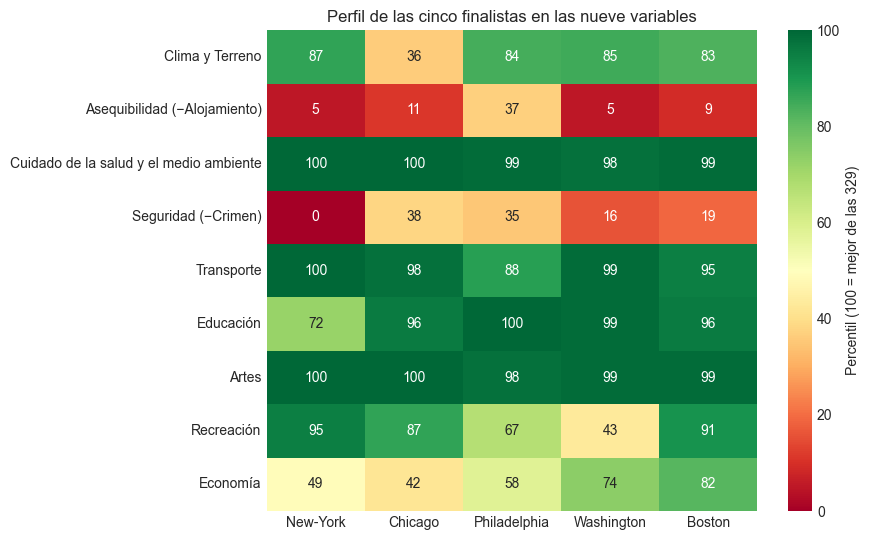

In [51]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(perfil_finalistas, annot=True, fmt='.0f', cmap='RdYlGn', center=50,
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Percentil (100 = mejor de las 329)'})
ax.set_title('Perfil de las cinco finalistas en las nueve variables')
plt.tight_layout()
plt.show()

El perfil revela un patrón compartido y una advertencia seria.

**Lo que las cinco tienen en común.** Todas están en el percentil 98 o superior en Salud y en Artes, y en el percentil 88 o superior en Transporte. Es el perfil de oferta metropolitana que define a PC1, y es la razón por la que ninguna variación de pesos logra sacarlas del top 5.

**La advertencia.** Las cinco pagan ese perfil con vivienda cara y menor seguridad, y no todas en la misma medida.

- **Nueva York está en el percentil 0 de Seguridad**, es decir es literalmente la ciudad menos segura de las 329, y en el percentil 5 de Asequibilidad. Para una sede que debe reubicar 500 empleados con sus familias, este es un riesgo que el comité debe conocer antes de decidir, no después.
- **Washington D.C.** también queda en el percentil 5 de Asequibilidad, con Recreación mediocre (percentil 43).
- **Filadelfia** es la más equilibrada de las cinco, la única con Asequibilidad cercana a la mediana (percentil 37) y con la mejor Educación de toda la muestra (percentil 100).
- **Boston** tiene la economía local más fuerte del grupo (percentil 82), lo que compensa parcialmente la penalización que el índice impone a esa variable.
- **Chicago** tiene el clima menos favorable (percentil 36), la única de las cinco por debajo de la mediana en esa variable.

Estas fortalezas y debilidades son el insumo directo del Paso 6, donde formulamos la recomendación y el trade off que implica cada opción.

### Cierre del Paso 5. hallazgos clave

1. **Sensibilidad a los pesos.** Probamos ocho esquemas y comparamos con correlación de Spearman y coincidencias en el top 5. Los pesos sí influyen, y de forma sistemática. La disputa real no es quién gana, sino Boston y Filadelfia (si se prioriza solidez institucional) contra Los Ángeles y San Francisco (si se prioriza escala o clima).
2. **Número de componentes.** Usar 4 componentes en lugar de 3 da correlación 0.932 con el esquema base y un top 5 idéntico. La decisión del Paso 2 no tuvo consecuencias sobre el resultado.
3. **Observación extrema.** Reajustar el PCA completo sin Nueva York produce loadings con correlación superior a 0.99 y un ranking con correlación 0.993. La estructura de los componentes no depende de esa observación.
4. **Ciudades atípicas.** Se reparten en dos grupos opuestos. Las de gran oferta metropolitana quedan en el top 15, las de economía local muy fuerte (Midland, Lafayette) quedan en los dos últimos lugares, penalizadas por el peso implícito negativo de Economía. Es una limitación documentada del índice.
5. **Finalistas.** Aplicando como criterio la frecuencia de aparición en el top 5 a lo largo de los cinco esquemas coherentes con el negocio, quedan seleccionadas **Nueva York, Chicago, Filadelfia y Washington D.C.** (5 de 5 apariciones) y **Boston** (3 de 5).
6. **Riesgo a advertir.** Nueva York encabeza el ranking pero es la ciudad menos segura de las 329 y está entre el 5% menos asequible. Filadelfia es la más equilibrada del grupo. Este contraste es el eje del trade off que presentaremos al comité en el Paso 6.